In [3]:

from pathlib import Path
import os
import random
import shutil
import zipfile
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

IN_KAGGLE = Path("/kaggle/input").exists()

if IN_KAGGLE:
    DATA_ROOT = Path("/kaggle/input")                    # read-only input datasets
    WORK_ROOT = Path("/kaggle/working/cv_kaggle_work")   # writable working folder
else:
    DATA_ROOT = Path.cwd()
    WORK_ROOT = Path.cwd() / "cv_kaggle_work"

PROJECT_DIR = WORK_ROOT  # writable folder for models / reports / submissions
WORK_ROOT.mkdir(parents=True, exist_ok=True)
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

if IN_KAGGLE and len(list(DATA_ROOT.iterdir())) == 0:
    raise FileNotFoundError(
        "В Kaggle справа сейчас нет подключенных Input.\n"
        "Нажми справа Add Input и добавь датасет соревнования, потом запусти блок заново."
    )


def is_real_file(path: Path) -> bool:
    return (
        path.is_file()
        and not path.name.startswith(".")
        and not path.name.startswith("._")
        and "__MACOSX" not in str(path)
    )

def find_first_file(root: Path, patterns):
    """Find first matching file recursively."""
    candidates = []
    for pattern in patterns:
        candidates.extend([p for p in root.rglob(pattern) if is_real_file(p)])
    candidates = sorted(set(candidates), key=lambda p: (len(str(p)), str(p)))
    return candidates[0] if candidates else None

def find_submission_template(root: Path) -> Path:
    candidates = []
    for name in ["sample_submission.csv", "submission.csv", "Sample_Submission.csv"]:
        candidates.extend([p for p in root.rglob(name) if is_real_file(p)])
    if not candidates:
        candidates.extend([p for p in root.rglob("*submission*.csv") if is_real_file(p)])
        candidates.extend([p for p in root.rglob("*Submission*.csv") if is_real_file(p)])
    candidates = sorted(set(candidates), key=lambda p: (len(str(p)), str(p)))
    if not candidates:
        raise FileNotFoundError(
            f"Не найден sample_submission.csv внутри {root}.\n"
            "Проверь, что ты подключила именно датасет соревнования через Add Input."
        )
    return candidates[0]

SAMPLE_SUBMISSION_PATH = find_submission_template(DATA_ROOT)

# Optional zip paths. If dataset is already unzipped, later blocks will use folders directly.
_train_zip = find_first_file(DATA_ROOT, ["*train*.zip", "train.zip"])
_test_zip = find_first_file(DATA_ROOT, ["*test*.zip", "test.zip"])

if _train_zip is not None:
    TRAIN_ZIP_PATH = _train_zip
if _test_zip is not None:
    TEST_ZIP_PATH = _test_zip

print("IN_KAGGLE:", IN_KAGGLE)
print("DATA_ROOT:", DATA_ROOT)
print("WORK_ROOT:", WORK_ROOT)
print("PROJECT_DIR / outputs:", PROJECT_DIR)
print("SAMPLE_SUBMISSION_PATH:", SAMPLE_SUBMISSION_PATH)
print("TRAIN_ZIP_PATH:", globals().get("TRAIN_ZIP_PATH", "not found, will search unzipped train folders"))
print("TEST_ZIP_PATH:", globals().get("TEST_ZIP_PATH", "not found, will search unzipped test folders"))

SEED = 993

def seed_everything(seed: int = 993):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass

seed_everything(SEED)
print("Seed fixed:", SEED)


IN_KAGGLE: True
DATA_ROOT: /kaggle/input
WORK_ROOT: /kaggle/working/cv_kaggle_work
PROJECT_DIR / outputs: /kaggle/working/cv_kaggle_work
SAMPLE_SUBMISSION_PATH: /kaggle/input/datasets/anasteysha13/data-for-dl/2026-cv-competition/sample_submission.csv
TRAIN_ZIP_PATH: not found, will search unzipped train folders
TEST_ZIP_PATH: not found, will search unzipped test folders
Seed fixed: 993


## 1. Установка и импорты

In [4]:

import sys
import subprocess


try:
    import ultralytics
    from ultralytics import YOLO
    print("ultralytics already installed:", ultralytics.__version__)
except ImportError:
    print("Installing ultralytics...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics"], check=True)
    import ultralytics
    from ultralytics import YOLO
    print("ultralytics installed:", ultralytics.__version__)

from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.patches as patches

try:
    import torch
    print("torch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
except Exception as e:
    print("Torch check failed:", e)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
N_CLASSES = 52


ultralytics already installed: 8.4.45
torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Поиск train-папок в Kaggle Input

На этом этапе **test не используется**. Блок умеет работать и с уже распакованным датасетом, и с `train.zip`.


In [5]:
from pathlib import Path
import shutil
import zipfile

RAW_DIR = WORK_ROOT / "raw_data"
TRAIN_RAW_DIR = RAW_DIR / "train_extracted"
TRAIN_RAW_DIR.mkdir(parents=True, exist_ok=True)


def is_real_file(path: Path) -> bool:
    return (
        path.is_file()
        and not path.name.startswith(".")
        and not path.name.startswith("._")
        and "__MACOSX" not in str(path)
    )

def count_images(folder: Path) -> int:
    return len([p for p in folder.iterdir() if is_real_file(p) and p.suffix.lower() in IMAGE_EXTENSIONS])

def count_labels(folder: Path) -> int:
    return len([p for p in folder.iterdir() if is_real_file(p) and p.suffix.lower() == ".txt"])

def find_train_dirs(root: Path):
    """
    Ищет train/images и train/labels.
    Поддерживает структуры:
    train/images + train/labels,
    train/train/images + train/train/labels,
    images + labels.
    """
    image_dirs = [
        p for p in root.rglob("images")
        if p.is_dir() and "__MACOSX" not in str(p) and "test" not in str(p).lower()
    ]

    candidates = []

    for img_dir in image_dirs:
        label_dir = img_dir.parent / "labels"
        if not label_dir.exists():
            continue

        n_img = count_images(img_dir)
        n_lbl = count_labels(label_dir)

        if n_img > 0 and n_lbl > 0:
            candidates.append((n_img, n_lbl, img_dir, label_dir))

    if len(candidates) == 0:
        return None, None

    candidates = sorted(candidates, key=lambda x: (x[0], x[1]), reverse=True)
    _, _, best_images_dir, best_labels_dir = candidates[0]
    return best_images_dir, best_labels_dir


TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR = find_train_dirs(DATA_ROOT)


if TRAIN_IMAGES_DIR is None or TRAIN_LABELS_DIR is None:
    if "TRAIN_ZIP_PATH" not in globals():
        raise FileNotFoundError(
            "Не найдены train/images и train/labels в /kaggle/input, и не найден train.zip.\n"
            "Проверь справа Add Input: должен быть подключен датасет соревнования."
        )

    TRAIN_ZIP_PATH = Path(TRAIN_ZIP_PATH)
    if not TRAIN_ZIP_PATH.exists():
        raise FileNotFoundError(f"Не найден train.zip: {TRAIN_ZIP_PATH}")

    LOCAL_TRAIN_ZIP_PATH = WORK_ROOT / TRAIN_ZIP_PATH.name

    if (not LOCAL_TRAIN_ZIP_PATH.exists()) or (LOCAL_TRAIN_ZIP_PATH.stat().st_size != TRAIN_ZIP_PATH.stat().st_size):
        print("Copying train.zip to local Kaggle working storage...")
        shutil.copy2(TRAIN_ZIP_PATH, LOCAL_TRAIN_ZIP_PATH)
    else:
        print("Local train.zip already exists.")

    if not any(TRAIN_RAW_DIR.iterdir()):
        print("Extracting train.zip...")
        with zipfile.ZipFile(LOCAL_TRAIN_ZIP_PATH, "r") as z:
            z.extractall(TRAIN_RAW_DIR)
        print("Train extraction finished.")
    else:
        print("train.zip already extracted.")

    TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR = find_train_dirs(TRAIN_RAW_DIR)

if TRAIN_IMAGES_DIR is None or TRAIN_LABELS_DIR is None:
    raise FileNotFoundError(
        "После поиска/распаковки всё равно не найдены train/images и train/labels.\n"
        f"DATA_ROOT: {DATA_ROOT}\nTRAIN_RAW_DIR: {TRAIN_RAW_DIR}"
    )

print("TRAIN_IMAGES_DIR:", TRAIN_IMAGES_DIR)
print("TRAIN_LABELS_DIR:", TRAIN_LABELS_DIR)
print("Train images:", count_images(TRAIN_IMAGES_DIR))
print("Train labels:", count_labels(TRAIN_LABELS_DIR))
print("SAMPLE_SUBMISSION_PATH:", SAMPLE_SUBMISSION_PATH)
print("Block 2 finished. Test data was not used.")


TRAIN_IMAGES_DIR: /kaggle/input/datasets/anasteysha13/data-for-dl/2026-cv-competition/train/train/images
TRAIN_LABELS_DIR: /kaggle/input/datasets/anasteysha13/data-for-dl/2026-cv-competition/train/train/labels
Train images: 1697
Train labels: 1697
SAMPLE_SUBMISSION_PATH: /kaggle/input/datasets/anasteysha13/data-for-dl/2026-cv-competition/sample_submission.csv
Block 2 finished. Test data was not used.


## 3. EDA по train и проверка разметки

Разметка ожидается в YOLO-формате: `class_id x_center y_center width height`, координаты нормализованы от 0 до 1.

Train images: 1697
Train labels: 1697
Images without labels: 0
Labels without images: 0

Image sizes:


,width,height,count
0,640,640,1697



Total objects: 10498
Bad label rows: 0
Unique classes: 52
Min class_id: 0
Max class_id: 51


,label_file,stem,class_id,x_center,y_center,box_width,box_height
0,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,16,0.554688,0.312500,0.090625,0.071094
1,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,16,0.632031,0.375781,0.096875,0.070312
2,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,45,0.486719,0.614062,0.110156,0.088281
3,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,20,0.492188,0.407813,0.135156,0.071094
4,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,37,0.475781,0.495312,0.145313,0.101562



Class distribution:


,objects_count,count
0,0,156
1,1,96
2,2,149
3,3,143
4,4,134
5,5,197
6,6,165
7,7,250
8,8,139
9,9,177


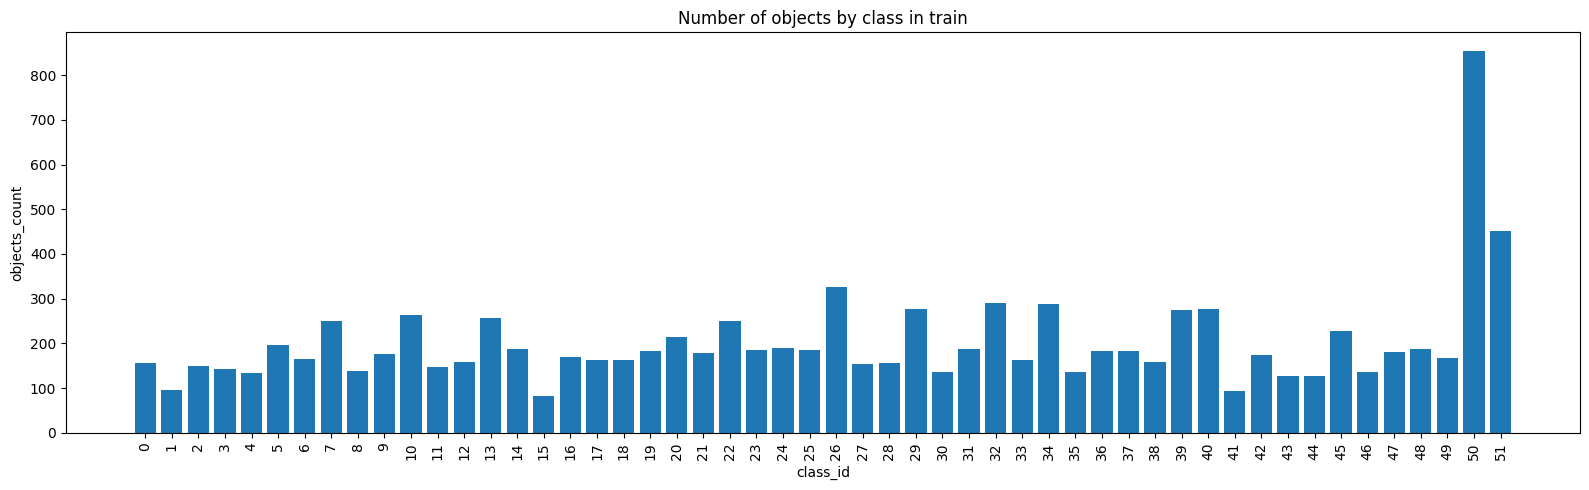

Invalid normalized boxes: 0

Objects per image summary:


count    1697.000000
mean        6.186211
std         2.660769
min         1.000000
25%         5.000000
50%         6.000000
75%         8.000000
max        16.000000
Name: objects_count, dtype: float64

In [6]:


train_images = sorted([p for p in TRAIN_IMAGES_DIR.iterdir() if is_real_file(p) and p.suffix.lower() in IMAGE_EXTENSIONS])
train_labels = sorted([p for p in TRAIN_LABELS_DIR.iterdir() if is_real_file(p) and p.suffix.lower() == ".txt"])

print("Train images:", len(train_images))
print("Train labels:", len(train_labels))

train_image_stems = set(p.stem for p in train_images)
train_label_stems = set(p.stem for p in train_labels)
print("Images without labels:", len(train_image_stems - train_label_stems))
print("Labels without images:", len(train_label_stems - train_image_stems))

# Размеры изображений
image_rows = []
for img_path in train_images:
    with Image.open(img_path) as img:
        width, height = img.size
    image_rows.append({"image_id": img_path.name, "stem": img_path.stem, "width": width, "height": height})

images_df = pd.DataFrame(image_rows)
print("\nImage sizes:")
display(images_df.groupby(["width", "height"]).size().reset_index(name="count").sort_values("count", ascending=False).head(20))

# Labels
label_rows = []
bad_label_rows = []

for label_path in train_labels:
    text = label_path.read_text(encoding="utf-8").strip()
    if text == "":
        continue

    for line_idx, line in enumerate(text.splitlines()):
        parts = line.strip().split()
        if len(parts) != 5:
            bad_label_rows.append({"label_file": label_path.name, "line_idx": line_idx, "line": line})
            continue

        try:
            label_rows.append({
                "label_file": label_path.name,
                "stem": label_path.stem,
                "class_id": int(float(parts[0])),
                "x_center": float(parts[1]),
                "y_center": float(parts[2]),
                "box_width": float(parts[3]),
                "box_height": float(parts[4]),
            })
        except Exception as e:
            bad_label_rows.append({"label_file": label_path.name, "line_idx": line_idx, "line": line, "error": str(e)})

labels_df = pd.DataFrame(label_rows)
bad_labels_df = pd.DataFrame(bad_label_rows)

print("\nTotal objects:", len(labels_df))
print("Bad label rows:", len(bad_labels_df))
print("Unique classes:", labels_df["class_id"].nunique())
print("Min class_id:", labels_df["class_id"].min())
print("Max class_id:", labels_df["class_id"].max())

display(labels_df.head())

class_distribution = labels_df["class_id"].value_counts().reindex(range(N_CLASSES), fill_value=0).sort_index()
print("\nClass distribution:")
display(class_distribution.reset_index().rename(columns={"index": "class_id", "class_id": "objects_count"}))

plt.figure(figsize=(16, 5))
plt.bar(class_distribution.index.astype(str), class_distribution.values)
plt.title("Number of objects by class in train")
plt.xlabel("class_id")
plt.ylabel("objects_count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Проверка bbox
invalid_bbox_mask = (
    (labels_df["class_id"] < 0) | (labels_df["class_id"] >= N_CLASSES) |
    (labels_df["x_center"] < 0) | (labels_df["x_center"] > 1) |
    (labels_df["y_center"] < 0) | (labels_df["y_center"] > 1) |
    (labels_df["box_width"] <= 0) | (labels_df["box_width"] > 1) |
    (labels_df["box_height"] <= 0) | (labels_df["box_height"] > 1)
)
print("Invalid normalized boxes:", int(invalid_bbox_mask.sum()))

objects_per_image = labels_df.groupby("stem").size().reset_index(name="objects_count")
print("\nObjects per image summary:")
display(objects_per_image["objects_count"].describe())


## 4. Визуальная sanity-check проверка train-разметки

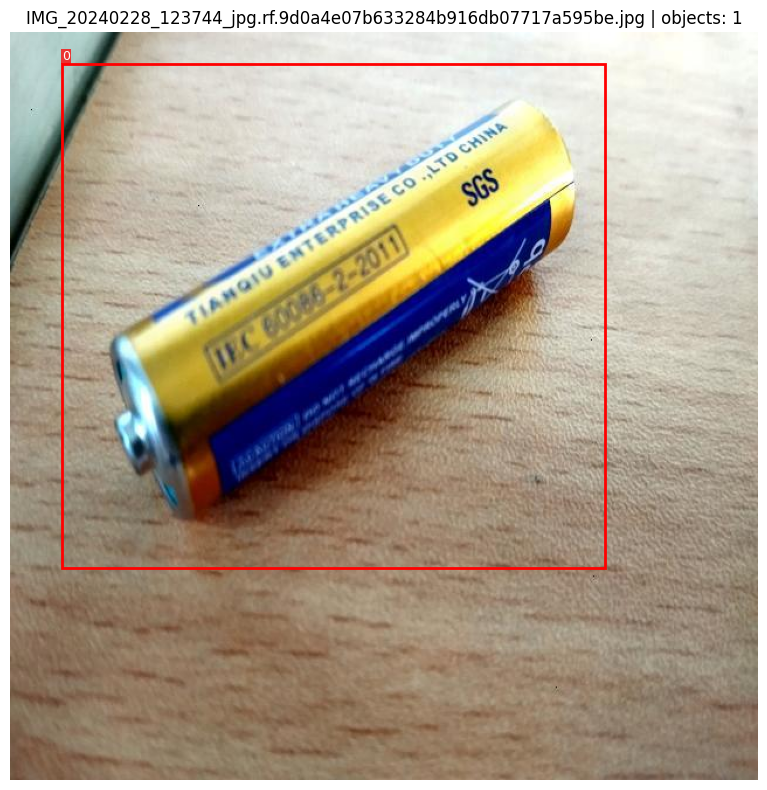

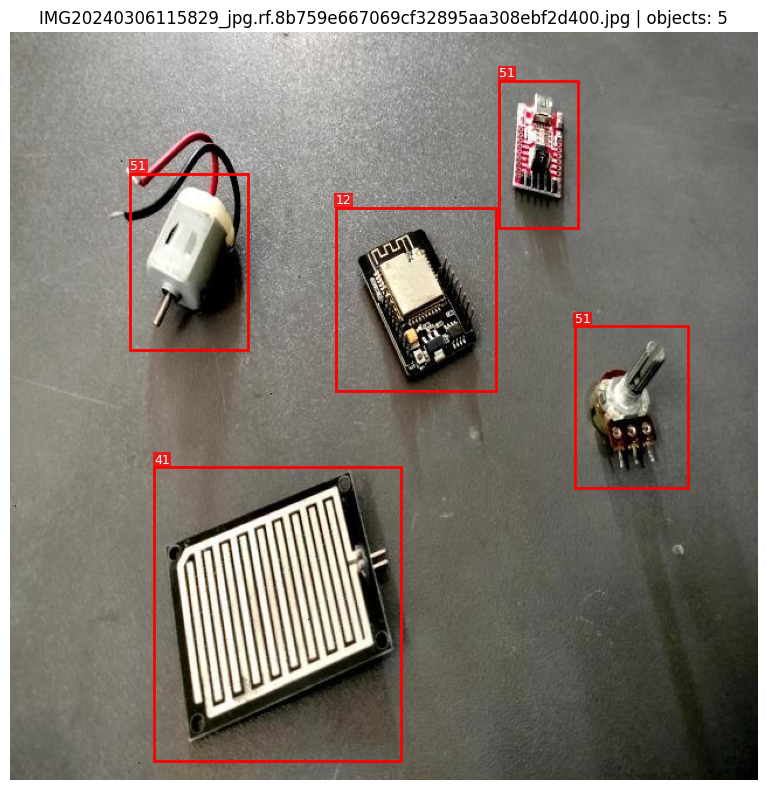

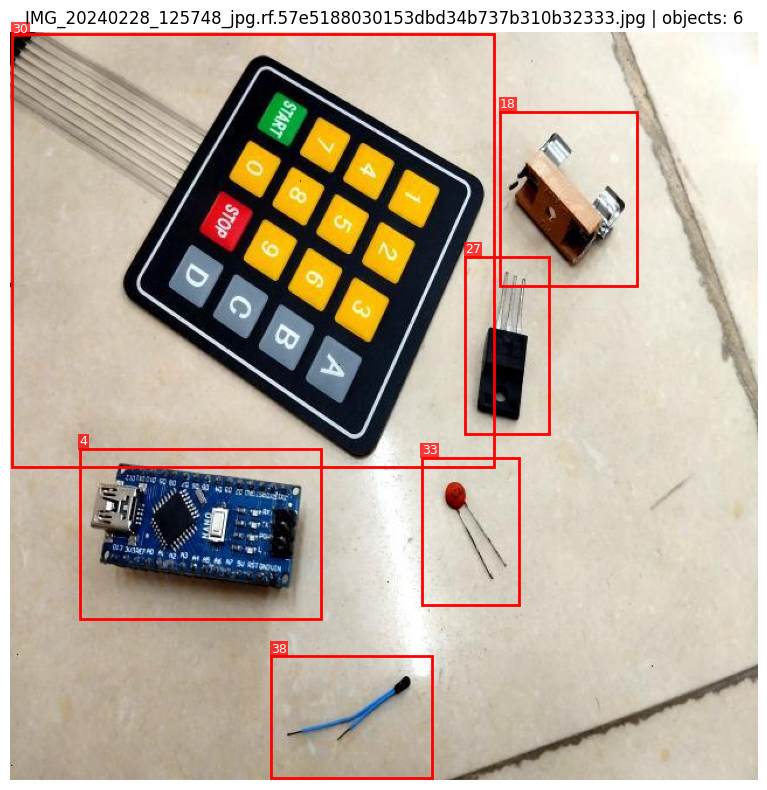

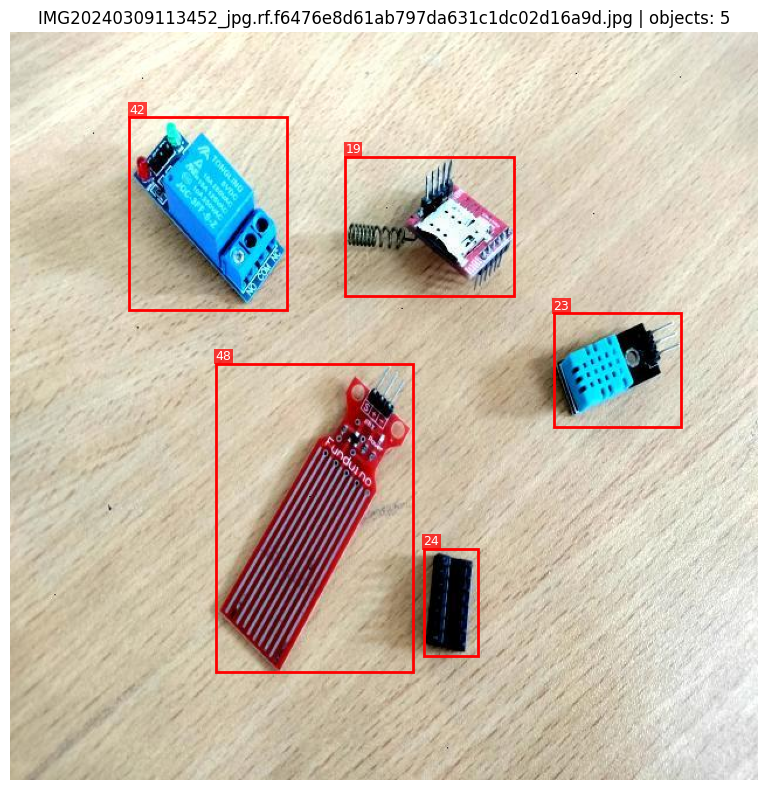

In [7]:

def show_image_with_boxes(image_path: Path, labels_table: pd.DataFrame, max_boxes: int = 80):
    image = Image.open(image_path).convert("RGB")
    width, height = image.size
    image_labels = labels_table[labels_table["stem"] == image_path.stem].copy()

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(image)
    ax.set_title(f"{image_path.name} | objects: {len(image_labels)}")
    ax.axis("off")

    if len(image_labels) > max_boxes:
        image_labels = image_labels.head(max_boxes)

    for _, row in image_labels.iterrows():
        x_min = (row["x_center"] - row["box_width"] / 2) * width
        y_min = (row["y_center"] - row["box_height"] / 2) * height
        box_w = row["box_width"] * width
        box_h = row["box_height"] * height

        rect = patches.Rectangle((x_min, y_min), box_w, box_h, linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x_min, max(y_min - 3, 0), str(int(row["class_id"])), fontsize=9, color="white",
                bbox=dict(facecolor="red", alpha=0.75, edgecolor="none", pad=1))

    plt.tight_layout()
    plt.show()

rng = np.random.default_rng(SEED)
images_with_labels = [p for p in train_images if p.stem in set(labels_df["stem"])]
sample_paths = rng.choice(images_with_labels, size=min(4, len(images_with_labels)), replace=False)
for p in sample_paths:
    show_image_with_boxes(Path(p), labels_df)


## 5. Препроцессинг train

Очищаем разметку и создаём `clean_train`. Test не используется.

In [8]:


CLEAN_TRAIN_DIR = WORK_ROOT / f"clean_train_seed_{SEED}"
CLEAN_IMAGES_DIR = CLEAN_TRAIN_DIR / "images"
CLEAN_LABELS_DIR = CLEAN_TRAIN_DIR / "labels"

if CLEAN_TRAIN_DIR.exists():
    shutil.rmtree(CLEAN_TRAIN_DIR)
CLEAN_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_LABELS_DIR.mkdir(parents=True, exist_ok=True)

labels_clean = labels_df.copy()
labels_clean["class_id"] = labels_clean["class_id"].astype(int)

valid_mask = (
    (labels_clean["class_id"] >= 0) & (labels_clean["class_id"] < N_CLASSES) &
    (labels_clean["x_center"] >= 0) & (labels_clean["x_center"] <= 1) &
    (labels_clean["y_center"] >= 0) & (labels_clean["y_center"] <= 1) &
    (labels_clean["box_width"] > 0) & (labels_clean["box_width"] <= 1) &
    (labels_clean["box_height"] > 0) & (labels_clean["box_height"] <= 1)
)

x_min_norm = labels_clean["x_center"] - labels_clean["box_width"] / 2
y_min_norm = labels_clean["y_center"] - labels_clean["box_height"] / 2
x_max_norm = labels_clean["x_center"] + labels_clean["box_width"] / 2
y_max_norm = labels_clean["y_center"] + labels_clean["box_height"] / 2

valid_mask = valid_mask & (x_min_norm >= -1e-6) & (y_min_norm >= -1e-6) & (x_max_norm <= 1 + 1e-6) & (y_max_norm <= 1 + 1e-6)

before_rows = len(labels_clean)
removed_rows = labels_clean.loc[~valid_mask].copy()
labels_clean = labels_clean.loc[valid_mask].copy()

print("Objects before cleaning:", before_rows)
print("Objects after cleaning:", len(labels_clean))
print("Removed objects:", len(removed_rows))
if len(removed_rows) > 0:
    display(removed_rows.head())

image_paths_by_stem = {p.stem: p for p in train_images}

for stem, img_path in image_paths_by_stem.items():
    shutil.copy2(img_path, CLEAN_IMAGES_DIR / img_path.name)

for stem in sorted(image_paths_by_stem.keys()):
    image_labels = labels_clean[labels_clean["stem"] == stem].copy()
    label_path = CLEAN_LABELS_DIR / f"{stem}.txt"

    if len(image_labels) == 0:
        label_path.write_text("", encoding="utf-8")
        continue

    image_labels = image_labels.sort_values(["class_id", "x_center", "y_center", "box_width", "box_height"])
    lines = []
    for _, row in image_labels.iterrows():
        lines.append(
            f"{int(row['class_id'])} "
            f"{float(row['x_center']):.8f} "
            f"{float(row['y_center']):.8f} "
            f"{float(row['box_width']):.8f} "
            f"{float(row['box_height']):.8f}"
        )
    label_path.write_text("\n".join(lines), encoding="utf-8")

# Обновляем основные переменные для следующих блоков.
TRAIN_IMAGES_DIR = CLEAN_IMAGES_DIR
TRAIN_LABELS_DIR = CLEAN_LABELS_DIR
train_images = sorted([p for p in TRAIN_IMAGES_DIR.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS])
train_labels = sorted([p for p in TRAIN_LABELS_DIR.iterdir() if p.is_file() and p.suffix.lower() == ".txt"])

# Пересобираем images_df и labels_df после clean_train.
clean_image_rows = []
for img_path in train_images:
    with Image.open(img_path) as img:
        width, height = img.size
    clean_image_rows.append({"image_id": img_path.name, "stem": img_path.stem, "width": width, "height": height})
images_df = pd.DataFrame(clean_image_rows)

clean_label_rows = []
for label_path in train_labels:
    text = label_path.read_text(encoding="utf-8").strip()
    if text == "":
        continue
    for line in text.splitlines():
        parts = line.strip().split()
        clean_label_rows.append({
            "label_file": label_path.name,
            "stem": label_path.stem,
            "class_id": int(parts[0]),
            "x_center": float(parts[1]),
            "y_center": float(parts[2]),
            "box_width": float(parts[3]),
            "box_height": float(parts[4]),
        })
labels_df = pd.DataFrame(clean_label_rows)

print("\nClean train images:", len(train_images))
print("Clean train labels:", len(train_labels))
print("Clean objects:", len(labels_df))
print("Clean unique classes:", labels_df["class_id"].nunique())
print("CLEAN_TRAIN_DIR:", CLEAN_TRAIN_DIR)


Objects before cleaning: 10498
Objects after cleaning: 10498
Removed objects: 0

Clean train images: 1697
Clean train labels: 1697
Clean objects: 10498
Clean unique classes: 52
CLEAN_TRAIN_DIR: /kaggle/working/cv_kaggle_work/clean_train_seed_993


## 6. Сбалансированный train/val split и data.yaml для YOLO

Split подбирается так, чтобы доля объектов каждого класса в validation была около 20%.

In [9]:


VAL_RATIO = 0.20
N_SPLIT_TRIES = 5000
rng = np.random.default_rng(SEED)

image_paths_by_stem = {Path(p).stem: Path(p) for p in train_images}
label_paths_by_stem = {Path(p).stem: Path(p) for p in train_labels}
all_image_stems = sorted(image_paths_by_stem.keys())
n_images = len(all_image_stems)
target_val_images = int(round(n_images * VAL_RATIO))

stem_to_idx = {stem: idx for idx, stem in enumerate(all_image_stems)}
image_class_matrix = np.zeros((n_images, N_CLASSES), dtype=np.int64)

for _, row in labels_df.iterrows():
    stem = row["stem"]
    class_id = int(row["class_id"])
    if stem in stem_to_idx and 0 <= class_id < N_CLASSES:
        image_class_matrix[stem_to_idx[stem], class_id] += 1

total_class_counts = image_class_matrix.sum(axis=0)
total_objects = int(total_class_counts.sum())
all_indices = np.arange(n_images)

print("Images:", n_images)
print("Objects:", total_objects)
print("Target val images:", target_val_images)
print("Classes with zero objects:", np.where(total_class_counts == 0)[0].tolist())

def evaluate_candidate_split(candidate_val_indices):
    candidate_val_indices = np.array(candidate_val_indices, dtype=int)
    val_counts = image_class_matrix[candidate_val_indices].sum(axis=0)
    train_counts = total_class_counts - val_counts
    val_object_share = val_counts.sum() / max(total_objects, 1)
    class_val_share = val_counts / np.maximum(total_class_counts, 1)
    deviation = np.abs(class_val_share - VAL_RATIO)

    score = (
        deviation.mean()
        + 0.20 * deviation.max()
        + 2.00 * abs(val_object_share - VAL_RATIO)
        + 5.00 * np.sum(val_counts == 0)
        + 5.00 * np.sum(train_counts == 0)
    )
    return score, val_counts, train_counts, class_val_share, val_object_share

best_score = float("inf")
best_val_indices = None
best_details = None

for _ in range(N_SPLIT_TRIES):
    candidate_val_indices = rng.choice(all_indices, size=target_val_images, replace=False)
    score, val_counts, train_counts, class_val_share, val_object_share = evaluate_candidate_split(candidate_val_indices)
    if score < best_score:
        best_score = score
        best_val_indices = candidate_val_indices.copy()
        best_details = (val_counts.copy(), train_counts.copy(), class_val_share.copy(), float(val_object_share))

val_counts, train_counts, class_val_share, val_object_share = best_details
val_idx_set = set(best_val_indices.tolist())
train_indices = [idx for idx in all_indices if idx not in val_idx_set]
val_indices = [idx for idx in all_indices if idx in val_idx_set]

train_image_stems = [all_image_stems[idx] for idx in train_indices]
val_image_stems = [all_image_stems[idx] for idx in val_indices]

print("\nBest split score:", round(best_score, 6))
print("Validation object share:", round(val_object_share, 4))
print("Train images:", len(train_image_stems))
print("Val images:", len(val_image_stems))

split_check_df = pd.DataFrame({
    "class_id": np.arange(N_CLASSES),
    "total_objects": total_class_counts.astype(int),
    "train_objects": train_counts.astype(int),
    "val_objects": val_counts.astype(int),
})
split_check_df["val_share"] = split_check_df["val_objects"] / split_check_df["total_objects"].replace(0, np.nan)
split_check_df["abs_deviation_from_20pct"] = (split_check_df["val_share"] - VAL_RATIO).abs()

print("\nValidation share summary:")
display(split_check_df["val_share"].describe())
print("Worst classes by deviation:")
display(split_check_df.sort_values("abs_deviation_from_20pct", ascending=False).head(15))

# Создаём YOLO dataset
YOLO_DATASET_DIR = WORK_ROOT / f"yolo_dataset_seed_{SEED}_balanced"
if YOLO_DATASET_DIR.exists():
    shutil.rmtree(YOLO_DATASET_DIR)

for split_name in ["train", "val"]:
    (YOLO_DATASET_DIR / split_name / "images").mkdir(parents=True, exist_ok=True)
    (YOLO_DATASET_DIR / split_name / "labels").mkdir(parents=True, exist_ok=True)

def copy_split_files(image_stem_list, split_name):
    images_out_dir = YOLO_DATASET_DIR / split_name / "images"
    labels_out_dir = YOLO_DATASET_DIR / split_name / "labels"

    for image_stem in image_stem_list:
        img_src = image_paths_by_stem[image_stem]
        lbl_src = label_paths_by_stem.get(image_stem)
        shutil.copy2(img_src, images_out_dir / img_src.name)
        label_dst = labels_out_dir / f"{image_stem}.txt"
        if lbl_src is not None and Path(lbl_src).exists():
            shutil.copy2(lbl_src, label_dst)
        else:
            label_dst.write_text("", encoding="utf-8")

copy_split_files(train_image_stems, "train")
copy_split_files(val_image_stems, "val")

split_df = pd.DataFrame({
    "stem": train_image_stems + val_image_stems,
    "split": ["train"] * len(train_image_stems) + ["val"] * len(val_image_stems),
})
SPLIT_CSV_PATH = YOLO_DATASET_DIR / f"split_seed_{SEED}_balanced.csv"
split_df.to_csv(SPLIT_CSV_PATH, index=False)

DATA_YAML_PATH = YOLO_DATASET_DIR / "data.yaml"
class_names = [f"class_{i}" for i in range(N_CLASSES)]
yaml_lines = [
    f"path: {YOLO_DATASET_DIR}",
    "train: train/images",
    "val: val/images",
    f"nc: {N_CLASSES}",
    "names:",
]
for class_id, class_name in enumerate(class_names):
    yaml_lines.append(f"  {class_id}: {class_name}")
DATA_YAML_PATH.write_text("\n".join(yaml_lines), encoding="utf-8")

print("\nYOLO_DATASET_DIR:", YOLO_DATASET_DIR)
print("DATA_YAML_PATH:", DATA_YAML_PATH)
print("YOLO train images:", len(list((YOLO_DATASET_DIR / "train" / "images").glob("*"))))
print("YOLO val images:", len(list((YOLO_DATASET_DIR / "val" / "images").glob("*"))))
print("Block 6 finished. Test data was not used.")


Images: 1697
Objects: 10498
Target val images: 339
Classes with zero objects: []

Best split score: 0.021919
Validation object share: 0.1997
Train images: 1358
Val images: 339

Validation share summary:


count    52.000000
mean      0.199568
std       0.016495
min       0.159509
25%       0.187961
50%       0.201230
75%       0.210292
max       0.228916
Name: val_share, dtype: float64

Worst classes by deviation:


,class_id,total_objects,train_objects,val_objects,val_share,abs_deviation_from_20pct
33,33,163,137,26,0.159509,0.040491
28,28,156,130,26,0.166667,0.033333
12,12,159,132,27,0.169811,0.030189
22,22,249,192,57,0.228916,0.028916
18,18,163,126,37,0.226994,0.026994
6,6,165,136,29,0.175758,0.024242
19,19,183,142,41,0.224044,0.024044
4,4,134,104,30,0.223881,0.023881
16,16,170,132,38,0.223529,0.023529
51,51,452,351,101,0.223451,0.023451



YOLO_DATASET_DIR: /kaggle/working/cv_kaggle_work/yolo_dataset_seed_993_balanced
DATA_YAML_PATH: /kaggle/working/cv_kaggle_work/yolo_dataset_seed_993_balanced/data.yaml
YOLO train images: 1358
YOLO val images: 339
Block 6 finished. Test data was not used.


## 6.5. Усиленные train-аугментации без изменения разметки

Добавляются только безопасные pixel-level аугментации: сильный Gaussian noise, sensor/salt-pepper noise, свет/контраст/цвет, gamma, JPEG-артефакты, blur/sharpen, точки, полосы, haze/vignette. 


In [10]:
# ============================================================
# Очистка недосохранённых augmented-файлов после ошибки
# ============================================================

from pathlib import Path
import shutil

WORK_ROOT_SAFE = Path(WORK_ROOT) if "WORK_ROOT" in globals() else Path("/kaggle/working/cv_kaggle_work")

for p in WORK_ROOT_SAFE.rglob("*aug*"):
    if p.is_dir():
        print("Удаляю папку:", p)
        shutil.rmtree(p)

print("Готово. Теперь заново запускай ячейку с augmentation.")

Готово. Теперь заново запускай ячейку с augmentation.


In [11]:
# ============================================================
# БЛОК 6.5. Усиленные offline-аугментации TRAIN
# test и val НЕ используются и НЕ изменяются


from pathlib import Path
from PIL import (
    Image, ImageEnhance, ImageDraw, ImageFile,
    ImageFilter, UnidentifiedImageError
)
from io import BytesIO
import numpy as np
import shutil
import random
import os

seed_everything(SEED)

# ------------------------------------------------------------
# НАСТРОЙКИ
# ------------------------------------------------------------
OFFLINE_AUGMENTATION = True

# Усиливаем train за счёт 4 pixel-level вариантов на изображение.
# Это не меняет bbox и не использует test/внешние данные.
# 4-й рецепт специально делает сильный Gaussian/sensor noise для роста recall на шумных тестовых картинках.
AUGMENT_VARIANTS_PER_IMAGE = 4
AUGMENT_MAX_IMAGES = None
AUGMENT_JPEG_QUALITY = 90

# Удаляем только ранее созданные __aug_ файлы, чтобы не смешивать старые/новые версии.
CLEAN_PREVIOUS_AUG_FILES = True

TRAIN_AUG_IMAGES_DIR = YOLO_DATASET_DIR / "train" / "images"
TRAIN_AUG_LABELS_DIR = YOLO_DATASET_DIR / "train" / "labels"

assert TRAIN_AUG_IMAGES_DIR.exists(), f"Не найдена train/images: {TRAIN_AUG_IMAGES_DIR}"
assert TRAIN_AUG_LABELS_DIR.exists(), f"Не найдена train/labels: {TRAIN_AUG_LABELS_DIR}"

if "IMAGE_EXTENSIONS" not in globals():
    IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"}

ImageFile.LOAD_TRUNCATED_IMAGES = True

# ------------------------------------------------------------
# СЛУЖЕБНЫЕ ФУНКЦИИ
# ------------------------------------------------------------
def _pil_rgb(image_path: Path) -> Image.Image:
    with Image.open(image_path) as img:
        return img.convert("RGB")


def add_rgb_gaussian_noise(img: Image.Image, rng: np.random.Generator, sigma_min=8, sigma_max=52) -> Image.Image:
    arr = np.asarray(img).astype(np.float32)
    sigma = float(rng.uniform(sigma_min, sigma_max))
    noise = rng.normal(loc=0.0, scale=sigma, size=arr.shape).astype(np.float32)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr, mode="RGB")


def add_salt_pepper_noise(img: Image.Image, rng: np.random.Generator, amount_min=0.002, amount_max=0.014) -> Image.Image:
    """Редкие белые/чёрные пиксели как sensor noise. Геометрию не меняет."""
    arr = np.asarray(img).copy()
    h, w = arr.shape[:2]
    amount = float(rng.uniform(amount_min, amount_max))
    n = int(max(1, h * w * amount))

    ys = rng.integers(0, h, size=n)
    xs = rng.integers(0, w, size=n)
    salt = rng.random(n) < 0.5
    arr[ys[salt], xs[salt], :] = 255
    arr[ys[~salt], xs[~salt], :] = 0
    return Image.fromarray(arr, mode="RGB")


def add_speckle_noise(img: Image.Image, rng: np.random.Generator, strength_min=0.04, strength_max=0.16) -> Image.Image:
    """Мультипликативный шум: полезен, если test содержит зерно/сжатие/низкое качество."""
    arr = np.asarray(img).astype(np.float32) / 255.0
    strength = float(rng.uniform(strength_min, strength_max))
    noise = rng.normal(0.0, strength, size=arr.shape).astype(np.float32)
    arr = arr + arr * noise
    arr = np.clip(arr * 255.0, 0, 255).astype(np.uint8)
    return Image.fromarray(arr, mode="RGB")


def add_color_jitter(img: Image.Image, rng: np.random.Generator, strong: bool = False) -> Image.Image:
    if strong:
        brightness = float(rng.uniform(0.65, 1.95))
        contrast = float(rng.uniform(0.70, 1.55))
        color = float(rng.uniform(0.70, 1.45))
        sharpness = float(rng.uniform(0.70, 1.80))
    else:
        brightness = float(rng.uniform(0.80, 1.55))
        contrast = float(rng.uniform(0.80, 1.35))
        color = float(rng.uniform(0.82, 1.25))
        sharpness = float(rng.uniform(0.85, 1.45))

    img = ImageEnhance.Brightness(img).enhance(brightness)
    img = ImageEnhance.Contrast(img).enhance(contrast)
    img = ImageEnhance.Color(img).enhance(color)
    img = ImageEnhance.Sharpness(img).enhance(sharpness)
    return img


def add_gamma(img: Image.Image, rng: np.random.Generator) -> Image.Image:
    gamma = float(rng.uniform(0.65, 1.55))
    inv = 1.0 / gamma
    table = [int(np.clip(((i / 255.0) ** inv) * 255.0, 0, 255)) for i in range(256)]
    return img.point(table * 3)


def add_overexposure(img: Image.Image, rng: np.random.Generator) -> Image.Image:
    img = ImageEnhance.Brightness(img).enhance(float(rng.uniform(1.20, 1.95)))
    img = ImageEnhance.Contrast(img).enhance(float(rng.uniform(0.85, 1.20)))

    w, h = img.size
    base = img.convert("RGBA")
    overlay = Image.new("RGBA", (w, h), (255, 255, 255, 0))
    draw = ImageDraw.Draw(overlay)

    for _ in range(int(rng.integers(1, 4))):
        cx = int(rng.integers(0, max(1, w)))
        cy = int(rng.integers(0, max(1, h)))
        rw = int(rng.integers(max(8, w // 10), max(9, w // 2)))
        rh = int(rng.integers(max(8, h // 10), max(9, h // 2)))
        alpha = int(rng.integers(35, 125))
        box = [
            max(0, cx - rw // 2),
            max(0, cy - rh // 2),
            min(w, cx + rw // 2),
            min(h, cy + rh // 2),
        ]
        if rng.random() < 0.60:
            draw.ellipse(box, fill=(255, 255, 255, alpha))
        else:
            draw.rectangle(box, fill=(255, 255, 255, alpha))

    return Image.alpha_composite(base, overlay).convert("RGB")


def add_vignette_or_haze(img: Image.Image, rng: np.random.Generator) -> Image.Image:
    w, h = img.size
    arr = np.asarray(img).astype(np.float32)

    yy, xx = np.mgrid[0:h, 0:w]
    cx = float(rng.uniform(0.35 * w, 0.65 * w))
    cy = float(rng.uniform(0.35 * h, 0.65 * h))
    dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
    dist = dist / (dist.max() + 1e-6)

    if rng.random() < 0.50:
        # лёгкая виньетка
        strength = float(rng.uniform(0.15, 0.38))
        mask = 1.0 - strength * (dist ** 1.4)
        arr = arr * mask[..., None]
    else:
        # лёгкая дымка/засветка
        strength = float(rng.uniform(0.08, 0.22))
        haze = 255.0 * strength * (1.0 - dist[..., None] * 0.35)
        arr = arr * (1.0 - strength) + haze

    arr = np.clip(arr, 0, 255).astype(np.uint8)
    return Image.fromarray(arr, mode="RGB")


def add_black_dots(img: Image.Image, rng: np.random.Generator) -> Image.Image:
    w, h = img.size
    base = img.convert("RGBA")
    overlay = Image.new("RGBA", (w, h), (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)

    base_count = max(14, min(110, int((w * h) / 16000)))
    n_dots = int(rng.integers(base_count, base_count * 3 + 1))
    max_radius = max(2, min(w, h) // 48)

    for _ in range(n_dots):
        r = int(rng.integers(1, max_radius + 1))
        x = int(rng.integers(0, max(1, w)))
        y = int(rng.integers(0, max(1, h)))
        alpha = int(rng.integers(70, 215))
        draw.ellipse([x - r, y - r, x + r, y + r], fill=(0, 0, 0, alpha))

    return Image.alpha_composite(base, overlay).convert("RGB")


def add_black_stripes(img: Image.Image, rng: np.random.Generator) -> Image.Image:
    w, h = img.size
    base = img.convert("RGBA")
    overlay = Image.new("RGBA", (w, h), (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)

    n_stripes = int(rng.integers(1, 6))
    for _ in range(n_stripes):
        vertical = bool(rng.integers(0, 2))
        alpha = int(rng.integers(40, 145))

        if vertical:
            thickness = int(rng.integers(max(2, w // 150), max(3, w // 32)))
            x = int(rng.integers(0, max(1, w)))
            draw.rectangle([x, 0, min(w, x + thickness), h], fill=(0, 0, 0, alpha))
        else:
            thickness = int(rng.integers(max(2, h // 150), max(3, h // 32)))
            y = int(rng.integers(0, max(1, h)))
            draw.rectangle([0, y, w, min(h, y + thickness)], fill=(0, 0, 0, alpha))

    return Image.alpha_composite(base, overlay).convert("RGB")


def add_blur_or_sharpen(img: Image.Image, rng: np.random.Generator) -> Image.Image:
    if rng.random() < 0.50:
        return img.filter(ImageFilter.GaussianBlur(radius=float(rng.uniform(0.25, 1.05))))
    return ImageEnhance.Sharpness(img).enhance(float(rng.uniform(1.25, 2.10)))


def add_jpeg_artifacts(img: Image.Image, rng: np.random.Generator) -> Image.Image:
    quality = int(rng.integers(58, 88))
    buffer = BytesIO()
    img.save(buffer, format="JPEG", quality=quality, subsampling=0, optimize=False, progressive=False)
    buffer.seek(0)
    with Image.open(buffer) as reloaded:
        return reloaded.convert("RGB")


def make_augmented_image(img: Image.Image, recipe_name: str, rng: np.random.Generator) -> Image.Image:
    # ВАЖНО: рецепты не меняют геометрию, bbox остаются корректными.
    # Усиление сделано именно pixel-level, чтобы bbox не поплыли.
    if recipe_name == "strong_light_noise":
        img = add_color_jitter(img, rng, strong=True)
        img = add_overexposure(img, rng)
        img = add_rgb_gaussian_noise(img, rng, 16, 58)
        img = add_vignette_or_haze(img, rng)

    elif recipe_name == "heavy_gaussian_sensor_noise":
        # Самый важный новый рецепт: сильный Gaussian + sensor/speckle noise.
        # Он должен учить модель не терять объекты на грязных/шумных test-картинках.
        img = add_color_jitter(img, rng, strong=True)
        img = add_gamma(img, rng)
        img = add_rgb_gaussian_noise(img, rng, 28, 78)
        img = add_speckle_noise(img, rng, 0.06, 0.18)
        img = add_salt_pepper_noise(img, rng, 0.003, 0.018)
        if rng.random() < 0.50:
            img = add_jpeg_artifacts(img, rng)

    elif recipe_name == "dark_contrast_dots":
        img = add_color_jitter(img, rng, strong=True)
        img = add_gamma(img, rng)
        img = add_black_dots(img, rng)
        img = add_rgb_gaussian_noise(img, rng, 12, 44)

    elif recipe_name == "jpeg_blur_stripes":
        img = add_color_jitter(img, rng, strong=False)
        img = add_blur_or_sharpen(img, rng)
        img = add_black_stripes(img, rng)
        img = add_rgb_gaussian_noise(img, rng, 8, 30)
        img = add_jpeg_artifacts(img, rng)

    elif recipe_name == "color_gamma_haze":
        img = add_color_jitter(img, rng, strong=True)
        img = add_gamma(img, rng)
        img = add_vignette_or_haze(img, rng)
        img = add_rgb_gaussian_noise(img, rng, 10, 36)

    else:
        raise ValueError(f"Unknown augmentation recipe: {recipe_name}")

    return img.convert("RGB")


def save_augmented_image(img: Image.Image, out_path: Path) -> bool:
    """Безопасное сохранение изображений для Kaggle/PIL."""
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    img = img.convert("RGB")
    suffix = out_path.suffix.lower()

    try:
        if suffix in [".jpg", ".jpeg"]:
            img.save(out_path, format="JPEG", quality=int(AUGMENT_JPEG_QUALITY), subsampling=0, optimize=False, progressive=False)
        elif suffix == ".png":
            img.save(out_path, format="PNG", optimize=False)
        else:
            out_path = out_path.with_suffix(".jpg")
            img.save(out_path, format="JPEG", quality=int(AUGMENT_JPEG_QUALITY), subsampling=0, optimize=False, progressive=False)
        return True

    except OSError as e:
        print(f"WARNING: PIL не смог сохранить {out_path.name}: {e}")
        print("Пробую сохранить через cv2...")
        try:
            import cv2
            arr = np.array(img)
            arr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
            if out_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
                out_path = out_path.with_suffix(".jpg")
            if out_path.suffix.lower() in [".jpg", ".jpeg"]:
                ok = cv2.imwrite(str(out_path), arr, [int(cv2.IMWRITE_JPEG_QUALITY), int(AUGMENT_JPEG_QUALITY)])
            else:
                ok = cv2.imwrite(str(out_path), arr)
            if not ok:
                raise OSError("cv2.imwrite вернул False")
            return True
        except Exception as e2:
            print(f"WARNING: cv2 тоже не смог сохранить {out_path.name}: {e2}")
            return False


# ------------------------------------------------------------
# ОЧИСТКА СТАРЫХ AUG-ФАЙЛОВ
# ------------------------------------------------------------
if OFFLINE_AUGMENTATION and CLEAN_PREVIOUS_AUG_FILES:
    removed_imgs = 0
    removed_lbls = 0

    for p in TRAIN_AUG_IMAGES_DIR.iterdir():
        if p.is_file() and "__aug_" in p.stem:
            try:
                p.unlink()
                removed_imgs += 1
            except Exception as e:
                print(f"WARNING: не удалось удалить {p}: {e}")

    for p in TRAIN_AUG_LABELS_DIR.iterdir():
        if p.is_file() and "__aug_" in p.stem and p.suffix.lower() == ".txt":
            try:
                p.unlink()
                removed_lbls += 1
            except Exception as e:
                print(f"WARNING: не удалось удалить {p}: {e}")

    print(f"Removed previous augmented images: {removed_imgs}")
    print(f"Removed previous augmented labels: {removed_lbls}")


# ------------------------------------------------------------

if OFFLINE_AUGMENTATION:
    rng = np.random.default_rng(SEED)
    recipes_all = [
        "strong_light_noise",
        "heavy_gaussian_sensor_noise",
        "dark_contrast_dots",
        "jpeg_blur_stripes",
        "color_gamma_haze",
    ]
    recipes = recipes_all[:int(AUGMENT_VARIANTS_PER_IMAGE)]

    original_train_images = sorted([
        p for p in TRAIN_AUG_IMAGES_DIR.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
        and "__aug_" not in p.stem
        and not p.name.startswith("._")
    ])

    if AUGMENT_MAX_IMAGES is not None:
        original_train_images = original_train_images[:int(AUGMENT_MAX_IMAGES)]

    created = 0
    skipped = 0
    failed = 0

    print("Original train images for augmentation:", len(original_train_images))
    print("AUGMENT_VARIANTS_PER_IMAGE:", AUGMENT_VARIANTS_PER_IMAGE)
    print("Recipes:", recipes)

    for img_idx, img_path in enumerate(original_train_images, start=1):
        label_src = TRAIN_AUG_LABELS_DIR / f"{img_path.stem}.txt"

        if not label_src.exists():
            # Для YOLO допустима пустая разметка.
            label_src.write_text("", encoding="utf-8")

        for recipe_name in recipes:
            out_stem = f"{img_path.stem}__aug_{recipe_name}_seed{SEED}"
            out_img_path = TRAIN_AUG_IMAGES_DIR / f"{out_stem}{img_path.suffix.lower()}"
            out_lbl_path = TRAIN_AUG_LABELS_DIR / f"{out_stem}.txt"

            if out_img_path.exists() and out_lbl_path.exists():
                skipped += 1
                continue

            try:
                img = _pil_rgb(img_path)
                img_aug = make_augmented_image(img, recipe_name, rng)
                save_ok = save_augmented_image(img_aug, out_img_path)

                if save_ok:
                    shutil.copy2(label_src, out_lbl_path)
                    created += 1
                else:
                    failed += 1
                    print(f"FAILED to save augmented image for: {img_path.name} | recipe={recipe_name}")

            except (UnidentifiedImageError, OSError, ValueError) as e:
                failed += 1
                print(f"FAILED image: {img_path.name} | recipe={recipe_name} | error={e}")
                continue
            except Exception as e:
                failed += 1
                print(f"UNEXPECTED ERROR: {img_path.name} | recipe={recipe_name} | error={e}")
                continue

        if img_idx % 100 == 0 or img_idx == len(original_train_images):
            print(
                f"Augmented {img_idx}/{len(original_train_images)} original images | "
                f"created={created}, skipped={skipped}, failed={failed}"
            )

    train_images_after_aug = sorted([
        p for p in TRAIN_AUG_IMAGES_DIR.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])
    train_labels_after_aug = sorted([
        p for p in TRAIN_AUG_LABELS_DIR.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    ])

    print("\nOffline augmentation finished.")
    print("Created augmented images:", created)
    print("Skipped existing augmented images:", skipped)
    print("Failed augmented images:", failed)
    print("Train images after augmentation:", len(train_images_after_aug))
    print("Train labels after augmentation:", len(train_labels_after_aug))

else:
    print("OFFLINE_AUGMENTATION=False, block skipped.")

print("Block 6.5 finished. Validation and test were not changed.")


Removed previous augmented images: 0
Removed previous augmented labels: 0
Original train images for augmentation: 1358
AUGMENT_VARIANTS_PER_IMAGE: 4
Recipes: ['strong_light_noise', 'heavy_gaussian_sensor_noise', 'dark_contrast_dots', 'jpeg_blur_stripes']
Augmented 100/1358 original images | created=400, skipped=0, failed=0
Augmented 200/1358 original images | created=800, skipped=0, failed=0
Augmented 300/1358 original images | created=1200, skipped=0, failed=0
Augmented 400/1358 original images | created=1600, skipped=0, failed=0
Augmented 500/1358 original images | created=2000, skipped=0, failed=0
Augmented 600/1358 original images | created=2400, skipped=0, failed=0
Augmented 700/1358 original images | created=2800, skipped=0, failed=0
Augmented 800/1358 original images | created=3200, skipped=0, failed=0
Augmented 900/1358 original images | created=3600, skipped=0, failed=0
Augmented 1000/1358 original images | created=4000, skipped=0, failed=0
Augmented 1100/1358 original images 

## 7. Обучение YOLO11L 

Це


In [12]:
seed_everything(SEED)

from pathlib import Path
import shutil
import pandas as pd
import numpy as np
import gc
import os

from ultralytics import YOLO

try:
    import torch
    if torch.cuda.is_available():
        DEVICE = 0
        DEVICE_TYPE = "cuda"
        GPU_NAME = torch.cuda.get_device_name(0)
        GPU_MEMORY_GB = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        DEVICE = "mps"
        DEVICE_TYPE = "mps"
        GPU_NAME = "mps"
        GPU_MEMORY_GB = None
    else:
        DEVICE = "cpu"
        DEVICE_TYPE = "cpu"
        GPU_NAME = "cpu"
        GPU_MEMORY_GB = None
except Exception:
    DEVICE = "cpu"
    DEVICE_TYPE = "cpu"
    GPU_NAME = "cpu"
    GPU_MEMORY_GB = None

print("DEVICE_TYPE:", DEVICE_TYPE)
print("GPU_NAME:", GPU_NAME)
print("GPU_MEMORY_GB:", GPU_MEMORY_GB)


# ------------------------------------------------------------
# 7.1. Целевые настройки
# ------------------------------------------------------------
PREFERRED_MODEL = "yolo11l"
BASE_WEIGHTS = "yolo11l.pt"

TARGET_TOTAL_EPOCHS = 25
PATIENCE = 15
BASE_IMG_SIZE = 768

# batch=8 ставим первой попыткой: если он влезает, обучение почти в 2 раза быстрее, чем batch=4.
# Fallback оставлен только как защита от OOM, чтобы не потерять весь запуск на Kaggle.
if DEVICE_TYPE == "cuda":
    PRIMARY_BATCHES = [8, 6, 4]
elif DEVICE_TYPE == "mps":
    PRIMARY_BATCHES = [4, 3, 2]
else:
    print("WARNING: GPU не найден. CPU-режим только для проверки кода, качество не оценивай.")
    PRIMARY_BATCHES = [1]
    TARGET_TOTAL_EPOCHS = 2
    PATIENCE = 1
    BASE_WEIGHTS = "yolo11n.pt"

def clear_memory():
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
    except Exception:
        pass


def read_run_info(run_dir: Path):
    results_csv = run_dir / "results.csv"
    info = {
        "results_csv": results_csv,
        "completed_epochs": 0,
        "map50": None,
        "best_epoch": None,
        "df": None,
    }

    if not results_csv.exists():
        return info

    try:
        df = pd.read_csv(results_csv)
        df.columns = [str(c).strip() for c in df.columns]
        info["df"] = df
        info["completed_epochs"] = int(len(df))

        map50_cols = [
            c for c in df.columns
            if "map50" in c.lower() and "map50-95" not in c.lower()
        ]

        if map50_cols and len(df) > 0:
            vals = pd.to_numeric(df[map50_cols[0]], errors="coerce")
            if vals.notna().sum() > 0:
                best_idx = int(vals.idxmax())
                info["map50"] = float(vals.loc[best_idx])
                info["best_epoch"] = best_idx + 1

    except Exception as e:
        print(f"WARNING: не удалось прочитать {results_csv}: {e}")

    return info


def collect_yolo11l_runs(search_roots):
    runs = {}

    for root in search_roots:
        root = Path(root)
        if not root.exists():
            continue

        for p in root.rglob("*.pt"):
            if p.name not in {"best.pt", "last.pt"}:
                continue

            text = str(p).lower()
            if PREFERRED_MODEL not in text and "11l" not in text:
                continue

            run_dir = p.parent.parent
            if run_dir not in runs:
                runs[run_dir] = {
                    "run_dir": run_dir,
                    "best": None,
                    "last": None,
                    "mtime": 0,
                    **read_run_info(run_dir),
                }

            if p.name == "best.pt":
                runs[run_dir]["best"] = p
            if p.name == "last.pt":
                runs[run_dir]["last"] = p

            runs[run_dir]["mtime"] = max(runs[run_dir]["mtime"], p.stat().st_mtime)

    return list(runs.values())


def choose_existing_run(runs):
    if not runs:
        return None

    completed = [r for r in runs if r["completed_epochs"] >= TARGET_TOTAL_EPOCHS and (r["best"] or r["last"])]
    if completed:
        return sorted(
            completed,
            key=lambda r: (
                -1 if r["map50"] is None else r["map50"],
                r["completed_epochs"],
                r["mtime"],
            ),
            reverse=True,
        )[0]

    unfinished_with_last = [r for r in runs if r["last"] is not None]
    if unfinished_with_last:
        return sorted(
            unfinished_with_last,
            key=lambda r: (
                r["completed_epochs"],
                -1 if r["map50"] is None else r["map50"],
                r["mtime"],
            ),
            reverse=True,
        )[0]

    with_best = [r for r in runs if r["best"] is not None]
    if with_best:
        return sorted(
            with_best,
            key=lambda r: (
                r["completed_epochs"],
                -1 if r["map50"] is None else r["map50"],
                r["mtime"],
            ),
            reverse=True,
        )[0]

    return None


def is_cuda_memory_error(err: Exception):
    message = str(err).lower()
    return any(x in message for x in ["out of memory", "cuda", "cublas", "cudnn"])


clear_memory()

PROJECT_RUNS_DIR = WORK_ROOT / "yolo_runs"
PROJECT_RUNS_DIR.mkdir(parents=True, exist_ok=True)

MANUAL_WARM_START_PATH = None
# Если нужно явно указать checkpoint:
# MANUAL_WARM_START_PATH = Path("/kaggle/working/cv_kaggle_work/yolo_runs/.../weights/last.pt")

manual_run = None
if MANUAL_WARM_START_PATH is not None:
    p = Path(MANUAL_WARM_START_PATH)
    manual_run = {
        "run_dir": p.parent.parent,
        "best": p if p.name == "best.pt" else None,
        "last": p if p.name == "last.pt" else None,
        "mtime": p.stat().st_mtime if p.exists() else 0,
        **read_run_info(p.parent.parent),
    }

existing_runs = collect_yolo11l_runs([WORK_ROOT, Path("/kaggle/working")])
selected_run = manual_run if manual_run is not None else choose_existing_run(existing_runs)

print("Найдено YOLO11L run/checkpoint:", len(existing_runs))
if selected_run is not None:
    print("Выбран run:", selected_run["run_dir"])
    print("completed_epochs:", selected_run["completed_epochs"])
    print("best_epoch:", selected_run["best_epoch"])
    print("mAP50:", selected_run["map50"])
    print("best.pt:", selected_run["best"])
    print("last.pt:", selected_run["last"])
else:
    print("Подходящий YOLO11L checkpoint не найден. Стартуем с pretrained:", BASE_WEIGHTS)


# ------------------------------------------------------------
# 7.3. Проверяем, нужно ли дообучать
# ------------------------------------------------------------
TRAIN_SKIPPED = False
WARM_START_USED = False
RESUME_FIRST = False

if selected_run is not None and selected_run["completed_epochs"] >= TARGET_TOTAL_EPOCHS:
    TRAIN_SKIPPED = True
    RUN_DIR = selected_run["run_dir"]
    BEST_MODEL_PATH = selected_run["best"] if selected_run["best"] is not None else selected_run["last"]
    LAST_MODEL_PATH = selected_run["last"] if selected_run["last"] is not None else BEST_MODEL_PATH
    RESULTS_CSV_PATH = RUN_DIR / "results.csv"

    print(f"\nОбучение уже дошло до целевых {TARGET_TOTAL_EPOCHS} эпох.")
    print("Лишние эпохи НЕ запускаю.")
    print("Использую найденный checkpoint:", BEST_MODEL_PATH)

else:
    if selected_run is not None:
        WARM_START_USED = True
        COMPLETED_EPOCHS = int(selected_run["completed_epochs"])

        if selected_run["last"] is not None:
            START_WEIGHTS = str(selected_run["last"])
            RESUME_FIRST = True
        else:
            START_WEIGHTS = str(selected_run["best"])

        EPOCHS_TO_RUN = max(1, TARGET_TOTAL_EPOCHS - COMPLETED_EPOCHS)
    else:
        COMPLETED_EPOCHS = 0
        START_WEIGHTS = BASE_WEIGHTS
        EPOCHS_TO_RUN = TARGET_TOTAL_EPOCHS

    print("\nSTART_WEIGHTS:", START_WEIGHTS)
    print("COMPLETED_EPOCHS:", COMPLETED_EPOCHS)
    print("TARGET_TOTAL_EPOCHS:", TARGET_TOTAL_EPOCHS)
    print("EPOCHS_TO_RUN:", EPOCHS_TO_RUN)
    print("RESUME_FIRST:", RESUME_FIRST)

if not TRAIN_SKIPPED:
    TRAIN_CONFIGS = []

    for b in PRIMARY_BATCHES:
        TRAIN_CONFIGS.append({"imgsz": BASE_IMG_SIZE, "batch": b, "tag": f"11l_768_bs{b}"})

    if DEVICE_TYPE == "cuda":
        # Уменьшаем размер только если YOLO11L + 768 вообще не помещается.
        for b in [4, 3, 2]:
            TRAIN_CONFIGS.append({"imgsz": 704, "batch": b, "tag": f"11l_704_bs{b}_fallback"})

        # batch=1 оставлен только как аварийный вариант, чтобы не потерять уже обученные веса.
        TRAIN_CONFIGS.append({"imgsz": 768, "batch": 1, "tag": "11l_768_bs1_emergency"})
    elif DEVICE_TYPE == "cpu":
        TRAIN_CONFIGS = [{"imgsz": 512, "batch": 1, "tag": "cpu_check"}]

    train_images_for_steps = list((YOLO_DATASET_DIR / "train" / "images").glob("*"))
    train_images_for_steps = [p for p in train_images_for_steps if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]
    train_count_for_steps = max(1, len(train_images_for_steps))
    print("\nПлан попыток обучения:")
    print("Train images сейчас:", train_count_for_steps)
    for cfg in TRAIN_CONFIGS:
        approx_steps = int(np.ceil(train_count_for_steps / cfg["batch"]))
        print(f"imgsz={cfg['imgsz']}, batch={cfg['batch']} -> примерно {approx_steps} шагов/эпоху, tag={cfg['tag']}")



train_results = None
last_error = None
successful_cfg = None
RUN_NAME = None
used_true_resume = False
true_resume_already_failed = False

if not TRAIN_SKIPPED:
    for cfg_idx, cfg in enumerate(TRAIN_CONFIGS, start=1):
        IMG_SIZE = int(cfg["imgsz"])
        BATCH_SIZE = int(cfg["batch"])

        run_mode = "resume" if RESUME_FIRST and not true_resume_already_failed else ("continue" if WARM_START_USED else "fresh")
        RUN_NAME = (
            f"{PREFERRED_MODEL}_seed{SEED}_{cfg['tag']}_"
            f"{run_mode}_target{TARGET_TOTAL_EPOCHS}_from{COMPLETED_EPOCHS}_fastsafe"
        )

        print("\n" + "=" * 90)
        print(f"TRAIN TRY {cfg_idx}/{len(TRAIN_CONFIGS)}")
        print("=" * 90)
        print("START_WEIGHTS:", START_WEIGHTS)
        print("RUN_NAME:", RUN_NAME)
        print("TARGET_TOTAL_EPOCHS:", TARGET_TOTAL_EPOCHS)
        print("EPOCHS_TO_RUN:", EPOCHS_TO_RUN)
        print("IMG_SIZE:", IMG_SIZE)
        print("BATCH_SIZE:", BATCH_SIZE)
        print("Ожидаемые шаги на эпоху примерно:", int(np.ceil(train_count_for_steps / max(1, BATCH_SIZE))))

        # 1) Если есть last.pt, сначала пробуем настоящий resume: он сохраняет optimizer/scheduler/номер эпохи.
        if RESUME_FIRST and not true_resume_already_failed:
            try:
                clear_memory()
                print("Пробую настоящий resume=True из last.pt с новым batch/imgsz.")
                model = YOLO(START_WEIGHTS)
                train_results = model.train(
                    resume=True,
                    epochs=TARGET_TOTAL_EPOCHS,
                    imgsz=IMG_SIZE,
                    batch=BATCH_SIZE,
                    workers=4 if DEVICE_TYPE == "cuda" else 0,
                    cache="disk" if DEVICE_TYPE == "cuda" else False,
                    plots=False,
                    amp=True,
                    device=DEVICE,
                )
                successful_cfg = cfg
                used_true_resume = True
                print("Training finished successfully with true resume:", successful_cfg)

                try:
                    RUN_DIR = Path(model.trainer.save_dir)
                except Exception:
                    RUN_DIR = selected_run["run_dir"]
                break

            except Exception as e:
                last_error = e
                print("True resume failed:", e)
                clear_memory()

                # Часто resume подтягивает старые тяжёлые args. Тогда продолжаем от весов как fine-tune.
                if is_cuda_memory_error(e):
                    print("Похоже на CUDA/OOM. На этом batch пробую безопасное продолжение от last.pt без true resume.")
                else:
                    print("True resume не сработал. Пробую безопасное продолжение от last.pt без true resume.")
                true_resume_already_failed = True

        
        try:
            clear_memory()
            model = YOLO(START_WEIGHTS)

            train_results = model.train(
                data=str(DATA_YAML_PATH),
                epochs=EPOCHS_TO_RUN,
                imgsz=IMG_SIZE,
                batch=BATCH_SIZE,
                seed=SEED,
                deterministic=True,
                device=DEVICE,
                workers=4 if DEVICE_TYPE == "cuda" else 0,
                project=str(PROJECT_RUNS_DIR),
                name=RUN_NAME,
                exist_ok=True,

                pretrained=True,
                optimizer="SGD",
                lr0=0.0025 if WARM_START_USED else 0.006,
                lrf=0.01,
                momentum=0.937,
                weight_decay=0.0005,
                patience=min(PATIENCE, max(3, EPOCHS_TO_RUN)),
                cos_lr=True,
                warmup_epochs=1 if WARM_START_USED else 2,
                warmup_momentum=0.8,
                warmup_bias_lr=0.03,
                nbs=64,
                amp=True,
                cache="disk" if DEVICE_TYPE == "cuda" else False,
                val=True,

                # Усиленная online-аугментация без перехода на маленькую модель.
                hsv_h=0.025,
                hsv_s=0.85,
                hsv_v=0.65,
                degrees=8.0,
                translate=0.15,
                scale=0.75,
                shear=3.0,
                perspective=0.0008,
                fliplr=0.50,
                flipud=0.00,
                mosaic=1.00,
                mixup=0.08,
                copy_paste=0.00,
                close_mosaic=min(8, max(3, EPOCHS_TO_RUN // 4)),
                erasing=0.20,

                save=True,
                save_period=-1,
                plots=False,
                verbose=True,
            )

            successful_cfg = cfg
            print("Training finished successfully with config:", successful_cfg)

            try:
                RUN_DIR = Path(model.trainer.save_dir)
            except Exception:
                RUN_DIR = PROJECT_RUNS_DIR / RUN_NAME
            break

        except RuntimeError as e:
            last_error = e
            print("Training RuntimeError:", e)
            clear_memory()

            if is_cuda_memory_error(e):
                print("Похоже на OOM/CUDA. Перехожу к следующему batch/config.")
                continue

            raise

        except Exception as e:
            last_error = e
            print("Training error:", e)
            clear_memory()
            print("Пробую следующую конфигурацию.")
            continue

    if train_results is None:
        raise RuntimeError(
            "Все YOLO11L-конфигурации упали. "
            "Я не переключалась автоматически на маленькую модель, чтобы не терять качество. "
            f"Последняя ошибка: {last_error}"
        )

    WEIGHTS_DIR = RUN_DIR / "weights"
    BEST_MODEL_PATH = WEIGHTS_DIR / "best.pt"
    LAST_MODEL_PATH = WEIGHTS_DIR / "last.pt"
    RESULTS_CSV_PATH = RUN_DIR / "results.csv"

    if not BEST_MODEL_PATH.exists() and LAST_MODEL_PATH.exists():
        print("best.pt не найден. Использую last.pt.")
        BEST_MODEL_PATH = LAST_MODEL_PATH


print("\nRUN_DIR:", RUN_DIR)
print("BEST_MODEL_PATH:", BEST_MODEL_PATH)
print("LAST_MODEL_PATH:", LAST_MODEL_PATH)

assert Path(BEST_MODEL_PATH).exists(), "Не найден ни best.pt, ни last.pt. Обучение завершилось некорректно."

if Path(RESULTS_CSV_PATH).exists():
    results_df = pd.read_csv(RESULTS_CSV_PATH)
    display(results_df.tail())

    map50_cols = [
        c for c in results_df.columns
        if "map50" in str(c).lower() and "map50-95" not in str(c).lower()
    ]
    if map50_cols and len(results_df) > 0:
        map50_col = map50_cols[0]
        vals = pd.to_numeric(results_df[map50_col], errors="coerce")
        if vals.notna().sum() > 0:
            best_row = results_df.loc[vals.idxmax()]
            print("Best epoch by", map50_col)
            display(best_row.to_frame(name="best_value"))

MODEL_SAVE_DIR = PROJECT_DIR / "models"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

if TRAIN_SKIPPED:
    suffix = "skipped_existing25"
elif WARM_START_USED:
    suffix = "resume_to25" if used_true_resume else "continue_to25_fast"
else:
    suffix = "fresh25_fast"

DRIVE_BEST_MODEL_PATH = MODEL_SAVE_DIR / f"best_{PREFERRED_MODEL}_seed{SEED}_{suffix}.pt"
shutil.copy2(BEST_MODEL_PATH, DRIVE_BEST_MODEL_PATH)

BEST_WEIGHTS_PATH = Path(BEST_MODEL_PATH)
MODEL_WEIGHTS_PATH = Path(BEST_MODEL_PATH)
TRAINED_MODEL_PATH = Path(BEST_MODEL_PATH)
TRAIN_RUN_DIR = Path(RUN_DIR)

print("Saved selected model to:", DRIVE_BEST_MODEL_PATH)
print(f"Block 7 finished. Target total epochs = {TARGET_TOTAL_EPOCHS}. Test data was not used.")


DEVICE_TYPE: cuda
GPU_NAME: Tesla T4
GPU_MEMORY_GB: 14.56317138671875
Найдено YOLO11L run/checkpoint: 0
Подходящий YOLO11L checkpoint не найден. Стартуем с pretrained: yolo11l.pt

START_WEIGHTS: yolo11l.pt
COMPLETED_EPOCHS: 0
TARGET_TOTAL_EPOCHS: 25
EPOCHS_TO_RUN: 25
RESUME_FIRST: False

План попыток обучения:
Train images сейчас: 6790
imgsz=768, batch=8 -> примерно 849 шагов/эпоху, tag=11l_768_bs8
imgsz=768, batch=6 -> примерно 1132 шагов/эпоху, tag=11l_768_bs6
imgsz=768, batch=4 -> примерно 1698 шагов/эпоху, tag=11l_768_bs4
imgsz=704, batch=4 -> примерно 1698 шагов/эпоху, tag=11l_704_bs4_fallback
imgsz=704, batch=3 -> примерно 2264 шагов/эпоху, tag=11l_704_bs3_fallback
imgsz=704, batch=2 -> примерно 3395 шагов/эпоху, tag=11l_704_bs2_fallback
imgsz=768, batch=1 -> примерно 6790 шагов/эпоху, tag=11l_768_bs1_emergency

TRAIN TRY 1/7
START_WEIGHTS: yolo11l.pt
RUN_NAME: yolo11l_seed993_11l_768_bs8_fresh_target25_from0_fastsafe
TARGET_TOTAL_EPOCHS: 25
EPOCHS_TO_RUN: 25
IMG_SIZE: 768
BATCH_

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
20,21,9426.06,0.97788,0.60749,1.32842,0.87738,0.88262,0.85454,0.55841,1.16927,0.76560,1.55495,0.000627,0.000627,0.000627
21,22,9872.13,0.95458,0.58149,1.32103,0.88048,0.87249,0.85251,0.55955,1.16400,0.75732,1.54277,0.000427,0.000427,0.000427
22,23,10318.10,0.93330,0.56148,1.30116,0.87432,0.88714,0.85513,0.55938,1.15479,0.75129,1.55164,0.000269,0.000269,0.000269
23,24,10763.90,0.92308,0.55209,1.29031,0.87758,0.88889,0.85540,0.56130,1.15249,0.74250,1.56720,0.000153,0.000153,0.000153
24,25,11209.60,0.91533,0.54818,1.28456,0.87577,0.88876,0.85567,0.56019,1.15629,0.74037,1.56607,0.000083,0.000083,0.000083


Best epoch by metrics/mAP50(B)


,best_value
epoch,14.000000
time,6298.020000
train/box_loss,1.242340
train/cls_loss,1.050200
train/dfl_loss,1.417170
metrics/precision(B),0.875240
metrics/recall(B),0.885760
metrics/mAP50(B),0.867420
metrics/mAP50-95(B),0.564400
val/box_loss,1.165080


Saved selected model to: /kaggle/working/cv_kaggle_work/models/best_yolo11l_seed993_fresh25_fast.pt
Block 7 finished. Target total epochs = 25. Test data was not used.


## 8. Validation без OOM и подбор порогов

Validation теперь строится с очень низкого raw confidence (`0.001`) и увеличенным `max_det`, чтобы логика подбора соответствовала финальному test inference с высоким recall. Test не используется.


In [13]:

from pathlib import Path
from ultralytics import YOLO
import pandas as pd
import numpy as np



REQUIRED_AFTER_TRAIN = ["BEST_MODEL_PATH", "DATA_YAML_PATH", "YOLO_DATASET_DIR", "IMG_SIZE", "SEED", "N_CLASSES"]
missing = [x for x in REQUIRED_AFTER_TRAIN if x not in globals()]
if missing:
    raise NameError("Не найдены переменные после обучения: " + ", ".join(missing) + "\nЗапусти блоки 0–7 или укажи BEST_MODEL_PATH вручную.")

BEST_MODEL_PATH = Path(BEST_MODEL_PATH)
DATA_YAML_PATH = Path(DATA_YAML_PATH)
YOLO_DATASET_DIR = Path(YOLO_DATASET_DIR)
VAL_IMAGES_DIR = YOLO_DATASET_DIR / "val" / "images"
VAL_LABELS_DIR = YOLO_DATASET_DIR / "val" / "labels"

assert BEST_MODEL_PATH.exists(), f"best.pt не найден: {BEST_MODEL_PATH}"
assert DATA_YAML_PATH.exists(), f"data.yaml не найден: {DATA_YAML_PATH}"
assert VAL_IMAGES_DIR.exists(), f"val/images не найден: {VAL_IMAGES_DIR}"
assert VAL_LABELS_DIR.exists(), f"val/labels не найден: {VAL_LABELS_DIR}"

print("BEST_MODEL_PATH:", BEST_MODEL_PATH)
print("DATA_YAML_PATH:", DATA_YAML_PATH)
print("YOLO_DATASET_DIR:", YOLO_DATASET_DIR)
print("VAL images:", len(list(VAL_IMAGES_DIR.glob('*'))))
print("VAL labels:", len(list(VAL_LABELS_DIR.glob('*.txt'))))
print("IMG_SIZE:", IMG_SIZE)
print("N_CLASSES:", N_CLASSES)


BEST_MODEL_PATH: /kaggle/working/cv_kaggle_work/yolo_runs/yolo11l_seed993_11l_768_bs8_fresh_target25_from0_fastsafe/weights/best.pt
DATA_YAML_PATH: /kaggle/working/cv_kaggle_work/yolo_dataset_seed_993_balanced/data.yaml
YOLO_DATASET_DIR: /kaggle/working/cv_kaggle_work/yolo_dataset_seed_993_balanced
VAL images: 678
VAL labels: 339
IMG_SIZE: 768
N_CLASSES: 52


In [14]:
# ============================================================
# БЛОК 8. Safe validation + подбор conf/class-wise thresholds без OOM
# test НЕ используется
# ============================================================

from pathlib import Path
from ultralytics import YOLO
from PIL import Image
import numpy as np
import pandas as pd
import gc
import random


REQUIRED_VARS = ["BEST_MODEL_PATH", "YOLO_DATASET_DIR", "IMG_SIZE", "SEED", "N_CLASSES"]
missing_vars = [name for name in REQUIRED_VARS if name not in globals()]
if missing_vars:
    raise NameError("Не найдены переменные: " + ", ".join(missing_vars) + "\nСначала запусти блоки 0–7.")

if "IMAGE_EXTENSIONS" not in globals():
    IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"}

BEST_MODEL_PATH = Path(BEST_MODEL_PATH)
YOLO_DATASET_DIR = Path(YOLO_DATASET_DIR)
VAL_IMAGES_DIR = YOLO_DATASET_DIR / "val" / "images"
VAL_LABELS_DIR = YOLO_DATASET_DIR / "val" / "labels"

assert BEST_MODEL_PATH.exists(), f"best.pt не найден: {BEST_MODEL_PATH}"
assert VAL_IMAGES_DIR.exists(), f"VAL_IMAGES_DIR не найден: {VAL_IMAGES_DIR}"
assert VAL_LABELS_DIR.exists(), f"VAL_LABELS_DIR не найден: {VAL_LABELS_DIR}"

val_image_paths = sorted([
    p for p in VAL_IMAGES_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS and not p.name.startswith("._")
])

if len(val_image_paths) == 0:
    raise FileNotFoundError(f"В {VAL_IMAGES_DIR} нет val images")

print("Validation images:", len(val_image_paths))
print("BEST_MODEL_PATH:", BEST_MODEL_PATH)

try:
    import torch
    if torch.cuda.is_available():
        DEVICE = 0
        DEVICE_TYPE = "cuda"
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        DEVICE = "mps"
        DEVICE_TYPE = "mps"
    else:
        DEVICE = "cpu"
        DEVICE_TYPE = "cpu"
except Exception:
    DEVICE = "cpu"
    DEVICE_TYPE = "cpu"

print("DEVICE_TYPE:", DEVICE_TYPE)


def read_yolo_label_file(label_path: Path, image_width: int, image_height: int):
    rows = []
    if not label_path.exists():
        return rows

    text = label_path.read_text(encoding="utf-8").strip()
    if text == "":
        return rows

    for line in text.splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue

        class_id = int(float(parts[0]))
        x_center, y_center, box_width, box_height = map(float, parts[1:])

        x_min = (x_center - box_width / 2) * image_width
        y_min = (y_center - box_height / 2) * image_height
        x_max = (x_center + box_width / 2) * image_width
        y_max = (y_center + box_height / 2) * image_height

        rows.append({
            "class_id": class_id,
            "box": np.array([x_min, y_min, x_max, y_max], dtype=np.float32),
        })
    return rows

gt_by_image = {}
gt_class_counts = np.zeros(N_CLASSES, dtype=int)

for image_path in val_image_paths:
    with Image.open(image_path) as img:
        width, height = img.size
    gt_rows = read_yolo_label_file(VAL_LABELS_DIR / f"{image_path.stem}.txt", width, height)
    gt_by_image[image_path.name] = gt_rows
    for row in gt_rows:
        if 0 <= int(row["class_id"]) < N_CLASSES:
            gt_class_counts[int(row["class_id"])] += 1

print("GT objects in val:", int(gt_class_counts.sum()))
print("Classes with GT in val:", int((gt_class_counts > 0).sum()))
print("Classes without GT in val:", np.where(gt_class_counts == 0)[0].tolist())


def box_iou_xyxy(box1, box2):
    x1 = max(float(box1[0]), float(box2[0]))
    y1 = max(float(box1[1]), float(box2[1]))
    x2 = min(float(box1[2]), float(box2[2]))
    y2 = min(float(box1[3]), float(box2[3]))
    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    area1 = max(0.0, float(box1[2]) - float(box1[0])) * max(0.0, float(box1[3]) - float(box1[1]))
    area2 = max(0.0, float(box2[2]) - float(box2[0])) * max(0.0, float(box2[3]) - float(box2[1]))
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0

def ap_from_precision_recall(recall, precision):
    if len(recall) == 0:
        return 0.0
    ap = 0.0
    for t in np.linspace(0, 1, 101):
        valid_precision = precision[recall >= t]
        ap += valid_precision.max() if valid_precision.size > 0 else 0.0
    return float(ap / 101.0)

def evaluate_single_class_ap50(class_id: int, pred_by_image: dict, gt_by_image: dict, conf_thr: float, iou_thr: float = 0.5):
    gt_for_class = {}
    n_gt = 0
    for image_key, gt_rows in gt_by_image.items():
        rows = [g for g in gt_rows if int(g["class_id"]) == class_id]
        if rows:
            gt_for_class[image_key] = rows
            n_gt += len(rows)

    if n_gt == 0:
        return {"class_id": class_id, "n_gt": 0, "n_pred": 0, "ap50": np.nan, "tp": 0, "fp": 0, "fn": 0, "threshold": conf_thr}

    class_preds = []
    for image_key, pred_rows in pred_by_image.items():
        for pred in pred_rows:
            if int(pred["class_id"]) == class_id and float(pred["conf"]) >= conf_thr:
                class_preds.append({"image_key": image_key, "conf": float(pred["conf"]), "box": pred["box"]})

    class_preds = sorted(class_preds, key=lambda x: x["conf"], reverse=True)
    matched = {image_key: np.zeros(len(rows), dtype=bool) for image_key, rows in gt_for_class.items()}

    tp, fp = [], []

    for pred in class_preds:
        image_key = pred["image_key"]
        pred_box = pred["box"]
        gt_rows = gt_for_class.get(image_key, [])
        best_iou, best_gt_idx = 0.0, -1

        for gt_idx, gt in enumerate(gt_rows):
            if matched[image_key][gt_idx]:
                continue
            current_iou = box_iou_xyxy(pred_box, gt["box"])
            if current_iou > best_iou:
                best_iou, best_gt_idx = current_iou, gt_idx

        if best_iou >= iou_thr and best_gt_idx >= 0:
            tp.append(1)
            fp.append(0)
            matched[image_key][best_gt_idx] = True
        else:
            tp.append(0)
            fp.append(1)

    if len(tp) == 0:
        return {"class_id": class_id, "n_gt": n_gt, "n_pred": 0, "ap50": 0.0, "tp": 0, "fp": 0, "fn": n_gt, "threshold": conf_thr}

    tp_arr = np.array(tp, dtype=float)
    fp_arr = np.array(fp, dtype=float)
    cum_tp = np.cumsum(tp_arr)
    cum_fp = np.cumsum(fp_arr)
    recall = cum_tp / max(n_gt, 1)
    precision = cum_tp / np.maximum(cum_tp + cum_fp, 1e-9)
    ap50 = ap_from_precision_recall(recall, precision)

    class_tp = int(cum_tp[-1])
    class_fp = int(cum_fp[-1])
    class_fn = int(max(0, n_gt - class_tp))

    return {
        "class_id": class_id,
        "n_gt": int(n_gt),
        "n_pred": int(len(class_preds)),
        "ap50": float(ap50),
        "tp": class_tp,
        "fp": class_fp,
        "fn": class_fn,
        "threshold": float(conf_thr),
    }

def evaluate_ap50(pred_by_image, gt_by_image, conf_thr: float, iou_thr: float = 0.5, class_thresholds=None):
    rows = []
    total_tp = total_fp = total_fn = total_pred = 0

    for class_id in range(N_CLASSES):
        thr = float(class_thresholds.get(class_id, conf_thr)) if class_thresholds is not None else float(conf_thr)
        row = evaluate_single_class_ap50(class_id, pred_by_image, gt_by_image, thr, iou_thr)
        rows.append(row)
        total_tp += int(row["tp"])
        total_fp += int(row["fp"])
        total_fn += int(row["fn"])
        total_pred += int(row["n_pred"])

    per_class_df = pd.DataFrame(rows)
    valid_ap = per_class_df["ap50"].dropna()
    ap50_val = float(valid_ap.mean()) if len(valid_ap) else 0.0
    precision = total_tp / max(total_tp + total_fp, 1)
    recall = total_tp / max(total_tp + total_fn, 1)

    return {
        "ap50_val": ap50_val,
        "precision_at_conf": float(precision),
        "recall_at_conf": float(recall),
        "tp": int(total_tp),
        "fp": int(total_fp),
        "fn": int(total_fn),
        "total_pred_boxes": int(total_pred),
        "mean_boxes_per_image": float(total_pred / max(len(pred_by_image), 1)),
        "classes_used": int((per_class_df["n_pred"] > 0).sum()),
        "per_class_df": per_class_df,
    }

NMS_IOU_THRESHOLD = 0.50
MAX_DET = 150
BEST_AUGMENT = False
RAW_VAL_CONF = 0.001

# Отдельная переменная для inference: если даже 768 не влезет, блок сам упадёт на 640.
INFERENCE_IMG_SIZE = int(min(IMG_SIZE, 768))

def clear_gpu():
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass

def predict_val_safely(img_size: int):
    pred_by_image = {}
    clear_gpu()
    model = YOLO(str(BEST_MODEL_PATH))

    print("\nRunning safe validation prediction...")
    print("img_size:", img_size)
    print("raw conf:", RAW_VAL_CONF)
    print("nms_iou:", NMS_IOU_THRESHOLD)
    print("max_det:", MAX_DET)
    print("augment:", False)

    for idx, image_path in enumerate(val_image_paths, start=1):
        with Image.open(image_path) as img:
            width, height = img.size

        results = model.predict(
            source=str(image_path),
            imgsz=img_size,
            conf=RAW_VAL_CONF,
            iou=NMS_IOU_THRESHOLD,
            max_det=MAX_DET,
            device=DEVICE,
            augment=False,
            half=(DEVICE_TYPE == "cuda"),
            verbose=False,
        )
        result = results[0]

        rows = []
        if result.boxes is not None and len(result.boxes) > 0:
            boxes = result.boxes.xyxy.cpu().numpy()
            confs = result.boxes.conf.cpu().numpy()
            classes = result.boxes.cls.cpu().numpy().astype(int)

            for box, conf, cls in zip(boxes, confs, classes):
                cls = int(cls)
                if 0 <= cls < N_CLASSES:
                    x1, y1, x2, y2 = box.astype(float)
                    x1 = float(np.clip(x1, 0, width))
                    y1 = float(np.clip(y1, 0, height))
                    x2 = float(np.clip(x2, 0, width))
                    y2 = float(np.clip(y2, 0, height))
                    if x2 > x1 and y2 > y1:
                        rows.append({
                            "class_id": cls,
                            "conf": float(conf),
                            "box": np.array([x1, y1, x2, y2], dtype=np.float32),
                        })

        pred_by_image[image_path.name] = rows

        del results, result
        clear_gpu()

        if idx % 25 == 0 or idx == len(val_image_paths):
            n_boxes_so_far = sum(len(v) for v in pred_by_image.values())
            print(f"Val predicted {idx}/{len(val_image_paths)} | boxes so far: {n_boxes_so_far}")

    return pred_by_image

try:
    pred_by_image = predict_val_safely(INFERENCE_IMG_SIZE)
except RuntimeError as e:
    message = str(e).lower()
    if "out of memory" in message or "cuda" in message:
        print("Validation OOM at img_size =", INFERENCE_IMG_SIZE)
        print("Fallback to img_size=640")
        clear_gpu()
        INFERENCE_IMG_SIZE = 640
        pred_by_image = predict_val_safely(INFERENCE_IMG_SIZE)
    else:
        raise

print("\nRaw validation predicted boxes:", sum(len(v) for v in pred_by_image.values()))
print("Mean raw boxes per image:", sum(len(v) for v in pred_by_image.values()) / max(len(pred_by_image), 1))

CONF_GRID = [
    0.001, 0.002, 0.003, 0.005, 0.008,
    0.010, 0.015, 0.020, 0.030, 0.050,
    0.080, 0.100, 0.150, 0.200, 0.300, 0.400
]
val_rows = []

for conf_thr in CONF_GRID:
    eval_result = evaluate_ap50(pred_by_image, gt_by_image, conf_thr=conf_thr, iou_thr=0.5)
    val_rows.append({
        "conf": conf_thr,
        "ap50_val": eval_result["ap50_val"],
        "precision": eval_result["precision_at_conf"],
        "recall": eval_result["recall_at_conf"],
        "tp": eval_result["tp"],
        "fp": eval_result["fp"],
        "fn": eval_result["fn"],
        "total_pred_boxes": eval_result["total_pred_boxes"],
        "mean_boxes_per_image": eval_result["mean_boxes_per_image"],
        "classes_used": eval_result["classes_used"],
    })
    print(
        f"conf={conf_thr:<5} | AP50={eval_result['ap50_val']:.5f} | "
        f"P={eval_result['precision_at_conf']:.4f} | R={eval_result['recall_at_conf']:.4f} | "
        f"boxes={eval_result['total_pred_boxes']}"
    )

val_grid_df = pd.DataFrame(val_rows).sort_values(
    ["ap50_val", "recall", "precision", "mean_boxes_per_image"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

print("\nTOP validation settings:")
display(val_grid_df)

best_row = val_grid_df.iloc[0]
BEST_CONF_THRESHOLD = float(best_row["conf"])
BEST_VAL_AP50_EST = float(best_row["ap50_val"])
BEST_VAL_PRECISION_EST = float(best_row["precision"])
BEST_VAL_RECALL_EST = float(best_row["recall"])

CLASS_THRESHOLDS = {c: BEST_CONF_THRESHOLD for c in range(N_CLASSES)}
CLASSWISE_ROWS = []

for class_id in range(N_CLASSES):
    if gt_class_counts[class_id] == 0:
        CLASS_THRESHOLDS[class_id] = BEST_CONF_THRESHOLD
        continue

    best_cls_ap = -1.0
    best_cls_thr = BEST_CONF_THRESHOLD
    best_cls_row = None

    for thr in CONF_GRID:
        row = evaluate_single_class_ap50(class_id, pred_by_image, gt_by_image, conf_thr=thr, iou_thr=0.5)
        cls_ap = float(row["ap50"])
        # При равном AP оставляем более низкий threshold, чтобы не убивать recall.
        if (cls_ap > best_cls_ap) or (np.isclose(cls_ap, best_cls_ap) and thr < best_cls_thr):
            best_cls_ap = cls_ap
            best_cls_thr = float(thr)
            best_cls_row = row

    CLASS_THRESHOLDS[class_id] = float(best_cls_thr)
    CLASSWISE_ROWS.append({
        "class_id": class_id,
        "n_gt": int(gt_class_counts[class_id]),
        "threshold": float(best_cls_thr),
        "class_ap50": float(best_cls_ap),
        "n_pred": int(best_cls_row["n_pred"]) if best_cls_row else 0,
    })

classwise_eval = evaluate_ap50(pred_by_image, gt_by_image, conf_thr=BEST_CONF_THRESHOLD, iou_thr=0.5, class_thresholds=CLASS_THRESHOLDS)
classwise_df = pd.DataFrame(CLASSWISE_ROWS).sort_values(["class_ap50", "n_gt"], ascending=[True, True])

print("\n" + "=" * 80)
print("FINAL PARAMS FROM SAFE VALIDATION")
print("=" * 80)
print("INFERENCE_IMG_SIZE:", INFERENCE_IMG_SIZE)
print("BEST_CONF_THRESHOLD:", BEST_CONF_THRESHOLD)
print("NMS_IOU_THRESHOLD:", NMS_IOU_THRESHOLD)
print("MAX_DET:", MAX_DET)
print("BEST_AUGMENT:", BEST_AUGMENT)
print("Estimated global VAL AP@0.5:", BEST_VAL_AP50_EST)
print("Estimated classwise VAL AP@0.5:", classwise_eval["ap50_val"])
print("Estimated global precision:", BEST_VAL_PRECISION_EST)
print("Estimated global recall:", BEST_VAL_RECALL_EST)

print("\nWorst classes after class-wise threshold search:")
display(classwise_df.head(15))

print("\nCLASS_THRESHOLDS:")
print(CLASS_THRESHOLDS)

# Сохраняем таблицы для анализа.
TUNING_DIR = PROJECT_DIR / "tuning_reports"
TUNING_DIR.mkdir(parents=True, exist_ok=True)
val_grid_df.to_csv(TUNING_DIR / f"safe_val_grid_seed{SEED}.csv", index=False)
classwise_df.to_csv(TUNING_DIR / f"safe_classwise_thresholds_seed{SEED}.csv", index=False)
print("\nSaved tuning reports to:", TUNING_DIR)

clear_gpu()
print("Block 8 finished without TTA and without heavy validation grid.")


Validation images: 339
BEST_MODEL_PATH: /kaggle/working/cv_kaggle_work/yolo_runs/yolo11l_seed993_11l_768_bs8_fresh_target25_from0_fastsafe/weights/best.pt
DEVICE_TYPE: cuda
GT objects in val: 2096
Classes with GT in val: 52
Classes without GT in val: []

Running safe validation prediction...
img_size: 768
raw conf: 0.001
nms_iou: 0.5
max_det: 150
augment: False
Val predicted 25/339 | boxes so far: 367
Val predicted 50/339 | boxes so far: 789
Val predicted 75/339 | boxes so far: 1184
Val predicted 100/339 | boxes so far: 1462
Val predicted 125/339 | boxes so far: 1942
Val predicted 150/339 | boxes so far: 2272
Val predicted 175/339 | boxes so far: 2608
Val predicted 200/339 | boxes so far: 2926
Val predicted 225/339 | boxes so far: 3335
Val predicted 250/339 | boxes so far: 3631
Val predicted 275/339 | boxes so far: 3904
Val predicted 300/339 | boxes so far: 4205
Val predicted 325/339 | boxes so far: 4488
Val predicted 339/339 | boxes so far: 4660

Raw validation predicted boxes: 4660
M

,conf,ap50_val,precision,recall,tp,fp,fn,total_pred_boxes,mean_boxes_per_image,classes_used
0,0.001,0.844613,0.416309,0.925573,1940,2720,156,4660,13.746313,52
1,0.003,0.844142,0.561612,0.924141,1937,1512,159,3449,10.174041,52
2,0.002,0.844142,0.513385,0.924141,1937,1836,159,3773,11.129794,52
3,0.005,0.843581,0.622265,0.922710,1934,1174,162,3108,9.168142,52
4,0.008,0.841792,0.677555,0.920324,1929,918,167,2847,8.398230,52
5,0.010,0.841278,0.703136,0.919847,1928,814,168,2742,8.088496,52
6,0.015,0.840362,0.737931,0.918893,1926,684,170,2610,7.699115,52
7,0.020,0.839077,0.761490,0.916985,1922,602,174,2524,7.445428,52
8,0.030,0.836858,0.788715,0.913645,1915,513,181,2428,7.162242,52
9,0.050,0.836159,0.819974,0.912691,1913,420,183,2333,6.882006,52



FINAL PARAMS FROM SAFE VALIDATION
INFERENCE_IMG_SIZE: 768
BEST_CONF_THRESHOLD: 0.001
NMS_IOU_THRESHOLD: 0.5
MAX_DET: 150
BEST_AUGMENT: False
Estimated global VAL AP@0.5: 0.8446134811510875
Estimated classwise VAL AP@0.5: 0.8446134811510875
Estimated global precision: 0.41630901287553645
Estimated global recall: 0.9255725190839694

Worst classes after class-wise threshold search:


,class_id,n_gt,threshold,class_ap50,n_pred
46,46,26,0.001,0.571653,73
49,49,30,0.001,0.573805,150
38,38,29,0.001,0.654388,71
6,6,29,0.001,0.663826,88
40,40,59,0.001,0.672511,163
15,15,18,0.001,0.682892,37
30,30,25,0.001,0.720054,146
28,28,26,0.001,0.734923,55
1,1,20,0.001,0.737005,25
41,41,19,0.001,0.764959,33



CLASS_THRESHOLDS:
{0: 0.001, 1: 0.001, 2: 0.001, 3: 0.001, 4: 0.001, 5: 0.001, 6: 0.001, 7: 0.001, 8: 0.001, 9: 0.001, 10: 0.001, 11: 0.001, 12: 0.001, 13: 0.001, 14: 0.001, 15: 0.001, 16: 0.001, 17: 0.001, 18: 0.001, 19: 0.001, 20: 0.001, 21: 0.001, 22: 0.001, 23: 0.001, 24: 0.001, 25: 0.001, 26: 0.001, 27: 0.001, 28: 0.001, 29: 0.001, 30: 0.001, 31: 0.001, 32: 0.001, 33: 0.001, 34: 0.001, 35: 0.001, 36: 0.001, 37: 0.001, 38: 0.001, 39: 0.001, 40: 0.001, 41: 0.001, 42: 0.001, 43: 0.001, 44: 0.001, 45: 0.001, 46: 0.001, 47: 0.001, 48: 0.001, 49: 0.001, 50: 0.001, 51: 0.001}

Saved tuning reports to: /kaggle/working/cv_kaggle_work/tuning_reports
Block 8 finished without TTA and without heavy validation grid.


## 8.6. Дополнительное улучшение без переобучения

Этот блок **не трогает обучение и не портит сохранённый best.pt**. Он аккуратно перебирает несколько безопасных вариантов NMS и порогов confidence на validation, затем выбирает лучший вариант для финального inference. Если дополнительная настройка не даст прироста, notebook сохранит прежний лучший режим.

In [15]:

from pathlib import Path
from ultralytics import YOLO
from PIL import Image
import numpy as np
import pandas as pd
import gc

try:
    from IPython.display import display
except Exception:
    display = print


RUN_ADVANCED_TUNING = False

REQUIRED_ADVANCED_VARS = [
    "BEST_MODEL_PATH", "YOLO_DATASET_DIR", "IMG_SIZE", "SEED", "N_CLASSES",
    "pred_by_image", "gt_by_image", "gt_class_counts",
    "evaluate_ap50", "evaluate_single_class_ap50",
    "BEST_CONF_THRESHOLD", "NMS_IOU_THRESHOLD", "MAX_DET", "INFERENCE_IMG_SIZE"
]
missing_advanced = [name for name in REQUIRED_ADVANCED_VARS if name not in globals()]
if missing_advanced:
    raise NameError("Для блока 8.6 не хватает переменных: " + ", ".join(missing_advanced) + "\nСначала запусти блок 8.")

if "PROJECT_DIR" not in globals():
    PROJECT_DIR = Path("/kaggle/working/cv_kaggle_work")
PROJECT_DIR = Path(PROJECT_DIR)

BEST_MODEL_PATH = Path(BEST_MODEL_PATH)
YOLO_DATASET_DIR = Path(YOLO_DATASET_DIR)
VAL_IMAGES_DIR = YOLO_DATASET_DIR / "val" / "images"
VAL_LABELS_DIR = YOLO_DATASET_DIR / "val" / "labels"

if "IMAGE_EXTENSIONS" not in globals():
    IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"}

val_image_paths = sorted([
    p for p in VAL_IMAGES_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS and not p.name.startswith("._")
])

BASE_TUNING_STATE = {
    "conf": float(BEST_CONF_THRESHOLD),
    "nms": float(NMS_IOU_THRESHOLD),
    "img_size": int(INFERENCE_IMG_SIZE),
    "class_thresholds": dict(CLASS_THRESHOLDS) if "CLASS_THRESHOLDS" in globals() else {c: float(BEST_CONF_THRESHOLD) for c in range(N_CLASSES)},
}

RAW_CLASS_THRESHOLDS = dict(BASE_TUNING_STATE["class_thresholds"])
RAW_BEST_CONF_THRESHOLD = float(BASE_TUNING_STATE["conf"])
RAW_NMS_IOU_THRESHOLD = float(BASE_TUNING_STATE["nms"])


ADVANCED_CONF_GRID = [
    0.001, 0.002, 0.003, 0.005, 0.008,
    0.010, 0.015, 0.020, 0.030, 0.040, 0.050,
    0.070, 0.080, 0.100, 0.120, 0.150, 0.180, 0.200, 0.250, 0.300, 0.400
]
ADVANCED_CONF_GRID = sorted(set(float(x) for x in ADVANCED_CONF_GRID + [float(BEST_CONF_THRESHOLD)]))

ADVANCED_NMS_GRID = [float(NMS_IOU_THRESHOLD), 0.45, 0.55, 0.60, 0.65]
ADVANCED_NMS_GRID = sorted(set(float(x) for x in ADVANCED_NMS_GRID))

RAW_ADVANCED_CONF = min(0.001, min(ADVANCED_CONF_GRID))
ADVANCED_MAX_DET = int(max(MAX_DET, 150))

print("ADVANCED TUNING SETTINGS")
print("BEST_MODEL_PATH:", BEST_MODEL_PATH)
print("val images:", len(val_image_paths))
print("img_size:", INFERENCE_IMG_SIZE)
print("conf grid:", ADVANCED_CONF_GRID)
print("nms grid:", ADVANCED_NMS_GRID)
print("raw prediction conf:", RAW_ADVANCED_CONF)
print("max_det:", ADVANCED_MAX_DET)


def clear_gpu_advanced():
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass


def predict_val_with_nms(nms_iou: float, raw_conf: float = RAW_ADVANCED_CONF, img_size: int = None):
    if img_size is None:
        img_size = int(INFERENCE_IMG_SIZE)

    current_pred_by_image = {}
    model_adv = YOLO(str(BEST_MODEL_PATH))
    clear_gpu_advanced()

    print("\nPredict validation for NMS:", nms_iou, "img_size:", img_size, "raw_conf:", raw_conf)

    for idx, image_path in enumerate(val_image_paths, start=1):
        with Image.open(image_path) as img:
            width, height = img.size

        results = model_adv.predict(
            source=str(image_path),
            imgsz=img_size,
            conf=raw_conf,
            iou=float(nms_iou),
            max_det=ADVANCED_MAX_DET,
            device=DEVICE,
            augment=False,
            half=(DEVICE_TYPE == "cuda"),
            verbose=False,
        )
        result = results[0]

        rows = []
        if result.boxes is not None and len(result.boxes) > 0:
            boxes = result.boxes.xyxy.cpu().numpy()
            confs = result.boxes.conf.cpu().numpy()
            classes = result.boxes.cls.cpu().numpy().astype(int)

            for box, conf, cls in zip(boxes, confs, classes):
                cls = int(cls)
                if 0 <= cls < N_CLASSES:
                    x1, y1, x2, y2 = box.astype(float)
                    x1 = float(np.clip(x1, 0, width))
                    y1 = float(np.clip(y1, 0, height))
                    x2 = float(np.clip(x2, 0, width))
                    y2 = float(np.clip(y2, 0, height))
                    if x2 > x1 and y2 > y1:
                        rows.append({
                            "class_id": cls,
                            "conf": float(conf),
                            "box": np.array([x1, y1, x2, y2], dtype=np.float32),
                        })

        current_pred_by_image[image_path.name] = rows

        del results, result
        clear_gpu_advanced()

        if idx % 50 == 0 or idx == len(val_image_paths):
            total_boxes = sum(len(v) for v in current_pred_by_image.values())
            print(f"NMS {nms_iou}: {idx}/{len(val_image_paths)} | boxes: {total_boxes}")

    del model_adv
    clear_gpu_advanced()
    return current_pred_by_image


def tune_thresholds_for_preds(current_pred_by_image, nms_iou: float):
    rows = []
    class_thresholds_by_conf = {}

    # 1) global thresholds
    for conf_thr in ADVANCED_CONF_GRID:
        ev = evaluate_ap50(current_pred_by_image, gt_by_image, conf_thr=conf_thr, iou_thr=0.5)
        rows.append({
            "kind": "global",
            "nms_iou": float(nms_iou),
            "conf": float(conf_thr),
            "ap50_val": ev["ap50_val"],
            "precision": ev["precision_at_conf"],
            "recall": ev["recall_at_conf"],
            "total_pred_boxes": ev["total_pred_boxes"],
            "mean_boxes_per_image": ev["mean_boxes_per_image"],
            "classes_used": ev["classes_used"],
        })

    global_df = pd.DataFrame([r for r in rows if r["kind"] == "global"])
    global_df = global_df.sort_values(
        ["ap50_val", "recall", "precision", "mean_boxes_per_image"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)
    best_global_conf = float(global_df.iloc[0]["conf"])

    # 2) class-wise thresholds for this NMS
    class_thresholds = {c: best_global_conf for c in range(N_CLASSES)}
    class_rows = []

    for class_id in range(N_CLASSES):
        if int(gt_class_counts[class_id]) == 0:
            continue

        best_cls_ap = -1.0
        best_cls_thr = best_global_conf
        best_cls_row = None

        for thr in ADVANCED_CONF_GRID:
            row = evaluate_single_class_ap50(class_id, current_pred_by_image, gt_by_image, conf_thr=thr, iou_thr=0.5)
            cls_ap = float(row["ap50"])
            # При почти одинаковом AP оставляем более низкий порог, чтобы не потерять recall.
            if (cls_ap > best_cls_ap) or (np.isclose(cls_ap, best_cls_ap, atol=1e-5) and float(thr) < best_cls_thr):
                best_cls_ap = cls_ap
                best_cls_thr = float(thr)
                best_cls_row = row

        class_thresholds[class_id] = float(best_cls_thr)
        class_rows.append({
            "class_id": int(class_id),
            "n_gt": int(gt_class_counts[class_id]),
            "threshold": float(best_cls_thr),
            "class_ap50": float(best_cls_ap),
            "n_pred": int(best_cls_row["n_pred"]) if best_cls_row else 0,
        })

    classwise_ev = evaluate_ap50(
        current_pred_by_image,
        gt_by_image,
        conf_thr=best_global_conf,
        iou_thr=0.5,
        class_thresholds=class_thresholds,
    )

    class_thresholds_by_conf["classwise"] = class_thresholds

    rows.append({
        "kind": "classwise_raw",
        "nms_iou": float(nms_iou),
        "conf": best_global_conf,
        "ap50_val": classwise_ev["ap50_val"],
        "precision": classwise_ev["precision_at_conf"],
        "recall": classwise_ev["recall_at_conf"],
        "total_pred_boxes": classwise_ev["total_pred_boxes"],
        "mean_boxes_per_image": classwise_ev["mean_boxes_per_image"],
        "classes_used": classwise_ev["classes_used"],
    })

    return pd.DataFrame(rows), class_thresholds, pd.DataFrame(class_rows)


if RUN_ADVANCED_TUNING:
    all_tuning_rows = []
    pred_cache_by_nms = {}
    threshold_cache_by_nms = {}
    class_rows_by_nms = {}

    for nms_iou in ADVANCED_NMS_GRID:
        try:
            if abs(float(nms_iou) - float(NMS_IOU_THRESHOLD)) < 1e-9:
                current_preds = pred_by_image
                print("\nUse existing validation predictions for NMS:", nms_iou)
            else:
                current_preds = predict_val_with_nms(nms_iou=nms_iou)

            pred_cache_by_nms[float(nms_iou)] = current_preds
            tuning_df_part, cls_thr, cls_rows_df = tune_thresholds_for_preds(current_preds, nms_iou=float(nms_iou))
            all_tuning_rows.append(tuning_df_part)
            threshold_cache_by_nms[float(nms_iou)] = cls_thr
            class_rows_by_nms[float(nms_iou)] = cls_rows_df

        except RuntimeError as e:
            msg = str(e).lower()
            if "out of memory" in msg or "cuda" in msg:
                print("OOM на advanced tuning для NMS", nms_iou, "— пропускаю этот вариант.")
                clear_gpu_advanced()
            else:
                raise

    advanced_tuning_df = pd.concat(all_tuning_rows, ignore_index=True)
    advanced_tuning_df = advanced_tuning_df.sort_values(
        ["ap50_val", "recall", "precision", "mean_boxes_per_image"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    print("\nADVANCED TUNING RESULTS")
    display(advanced_tuning_df)

    selected = advanced_tuning_df.iloc[0]
    SELECTED_POSTPROCESS_KIND = str(selected["kind"])
    NMS_IOU_THRESHOLD = float(selected["nms_iou"])
    BEST_CONF_THRESHOLD = float(selected["conf"])

    selected_preds = pred_cache_by_nms[float(NMS_IOU_THRESHOLD)]
    pred_by_image = selected_preds

    if SELECTED_POSTPROCESS_KIND == "classwise_raw":
        CLASS_THRESHOLDS = dict(threshold_cache_by_nms[float(NMS_IOU_THRESHOLD)])
    else:
        CLASS_THRESHOLDS = {c: float(BEST_CONF_THRESHOLD) for c in range(N_CLASSES)}

    # Robust-версия: не даём малочисленным классам слишком переобучить threshold по маленькому validation.
    # Она не заменяет raw-classwise, а создаёт дополнительный вариант для submission.
    MIN_GT_FOR_CLASSWISE = 8
    MIN_CLASS_AP_GAIN = 0.002

    global_per_class = evaluate_ap50(
        selected_preds,
        gt_by_image,
        conf_thr=BEST_CONF_THRESHOLD,
        iou_thr=0.5,
    )["per_class_df"]

    global_class_ap = {
        int(r["class_id"]): float(r["ap50"]) if pd.notna(r["ap50"]) else 0.0
        for _, r in global_per_class.iterrows()
    }

    raw_selected_thresholds = dict(threshold_cache_by_nms.get(float(NMS_IOU_THRESHOLD), CLASS_THRESHOLDS))
    ROBUST_CLASS_THRESHOLDS = {c: float(BEST_CONF_THRESHOLD) for c in range(N_CLASSES)}
    robust_rows = []

    for class_id in range(N_CLASSES):
        n_gt = int(gt_class_counts[class_id])
        raw_thr = float(raw_selected_thresholds.get(class_id, BEST_CONF_THRESHOLD))
        global_ap = float(global_class_ap.get(class_id, 0.0))

        raw_row = evaluate_single_class_ap50(class_id, selected_preds, gt_by_image, conf_thr=raw_thr, iou_thr=0.5)
        raw_ap = float(raw_row["ap50"]) if pd.notna(raw_row["ap50"]) else 0.0

        use_raw = (n_gt >= MIN_GT_FOR_CLASSWISE) and ((raw_ap - global_ap) >= MIN_CLASS_AP_GAIN)
        final_thr = raw_thr if use_raw else float(BEST_CONF_THRESHOLD)
        ROBUST_CLASS_THRESHOLDS[class_id] = float(final_thr)

        robust_rows.append({
            "class_id": int(class_id),
            "n_gt": n_gt,
            "global_thr": float(BEST_CONF_THRESHOLD),
            "raw_thr": raw_thr,
            "robust_thr": float(final_thr),
            "global_ap50": global_ap,
            "raw_ap50": raw_ap,
            "used_raw_threshold": bool(use_raw),
        })

    robust_eval = evaluate_ap50(
        selected_preds,
        gt_by_image,
        conf_thr=BEST_CONF_THRESHOLD,
        iou_thr=0.5,
        class_thresholds=ROBUST_CLASS_THRESHOLDS,
    )
    raw_classwise_eval = evaluate_ap50(
        selected_preds,
        gt_by_image,
        conf_thr=BEST_CONF_THRESHOLD,
        iou_thr=0.5,
        class_thresholds=raw_selected_thresholds,
    )

    robust_df = pd.DataFrame(robust_rows)

    print("\nSelected postprocessing:")
    print("SELECTED_POSTPROCESS_KIND:", SELECTED_POSTPROCESS_KIND)
    print("NMS_IOU_THRESHOLD:", NMS_IOU_THRESHOLD)
    print("BEST_CONF_THRESHOLD:", BEST_CONF_THRESHOLD)
    print("Raw classwise AP50:", raw_classwise_eval["ap50_val"], "boxes:", raw_classwise_eval["total_pred_boxes"])
    print("Robust classwise AP50:", robust_eval["ap50_val"], "boxes:", robust_eval["total_pred_boxes"])

    # Для основной classwise submission выбираем robust, если он почти не хуже raw.
    if robust_eval["ap50_val"] >= raw_classwise_eval["ap50_val"] - 0.002:
        CLASS_THRESHOLDS = dict(ROBUST_CLASS_THRESHOLDS)
        SELECTED_THRESHOLD_MODE = "robust_classwise"
    else:
        CLASS_THRESHOLDS = dict(raw_selected_thresholds)
        SELECTED_THRESHOLD_MODE = "raw_classwise"

    BEST_VAL_AP50_EST = float(max(float(selected["ap50_val"]), robust_eval["ap50_val"], raw_classwise_eval["ap50_val"]))

    ADVANCED_TUNING_DIR = PROJECT_DIR / "tuning_reports_advanced"
    ADVANCED_TUNING_DIR.mkdir(parents=True, exist_ok=True)
    advanced_tuning_df.to_csv(ADVANCED_TUNING_DIR / f"advanced_tuning_grid_seed{SEED}.csv", index=False)
    robust_df.to_csv(ADVANCED_TUNING_DIR / f"robust_class_thresholds_seed{SEED}.csv", index=False)

    print("\nFINAL POSTPROCESSING FOR BLOCK 10")
    print("SELECTED_THRESHOLD_MODE:", SELECTED_THRESHOLD_MODE)
    print("NMS_IOU_THRESHOLD:", NMS_IOU_THRESHOLD)
    print("BEST_CONF_THRESHOLD:", BEST_CONF_THRESHOLD)
    print("INFERENCE_IMG_SIZE:", INFERENCE_IMG_SIZE)
    print("Saved reports to:", ADVANCED_TUNING_DIR)
    print("\nWorst/most changed robust thresholds:")
    display(robust_df.sort_values(["used_raw_threshold", "n_gt"], ascending=[False, True]).head(20))
else:
    SELECTED_POSTPROCESS_KIND = "base_from_block8"
    SELECTED_THRESHOLD_MODE = "base_from_block8"
    ROBUST_CLASS_THRESHOLDS = dict(CLASS_THRESHOLDS)
    print("RUN_ADVANCED_TUNING=False: оставлены настройки блока 8.")

clear_gpu_advanced()
print("Block 8.6 finished. Test data was not used.")


ADVANCED TUNING SETTINGS
BEST_MODEL_PATH: /kaggle/working/cv_kaggle_work/yolo_runs/yolo11l_seed993_11l_768_bs8_fresh_target25_from0_fastsafe/weights/best.pt
val images: 339
img_size: 768
conf grid: [0.001, 0.002, 0.003, 0.005, 0.008, 0.01, 0.015, 0.02, 0.03, 0.04, 0.05, 0.07, 0.08, 0.1, 0.12, 0.15, 0.18, 0.2, 0.25, 0.3, 0.4]
nms grid: [0.45, 0.5, 0.55, 0.6, 0.65]
raw prediction conf: 0.001
max_det: 150
RUN_ADVANCED_TUNING=False: оставлены настройки блока 8.
Block 8.6 finished. Test data was not used.


## 9. Визуальная проверка предсказаний на validation

In [16]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


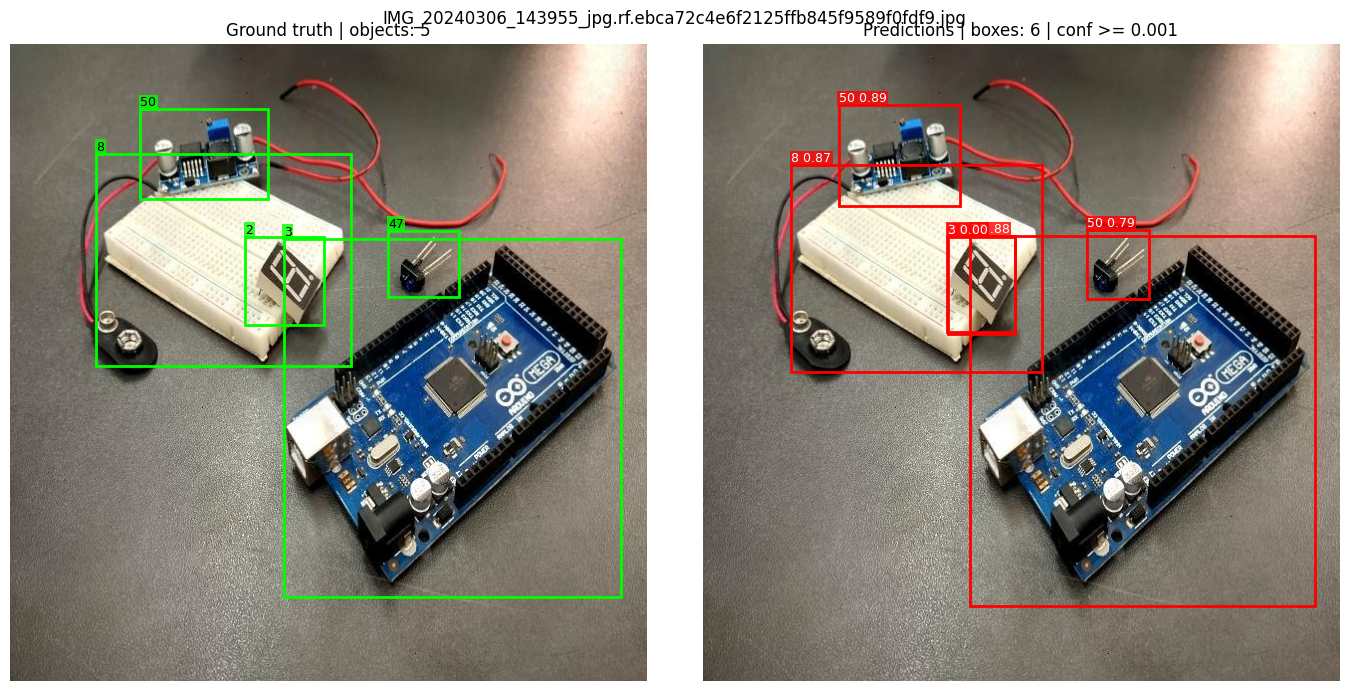

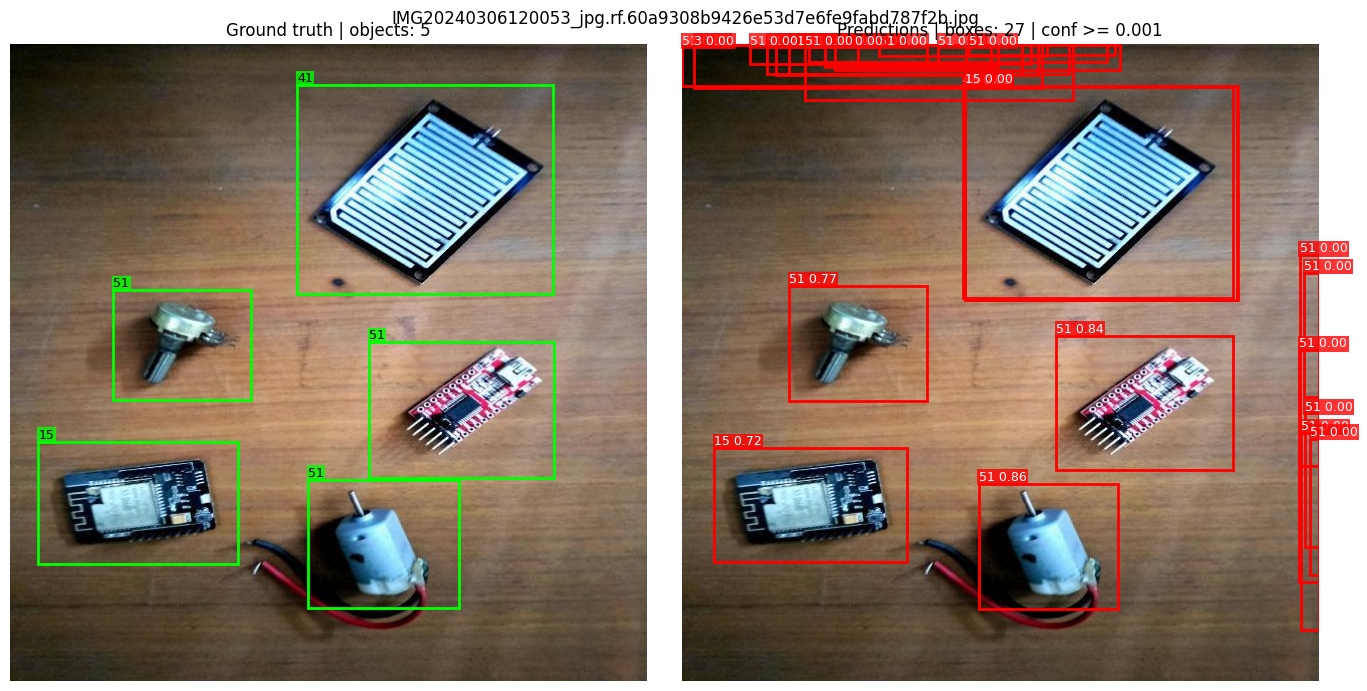

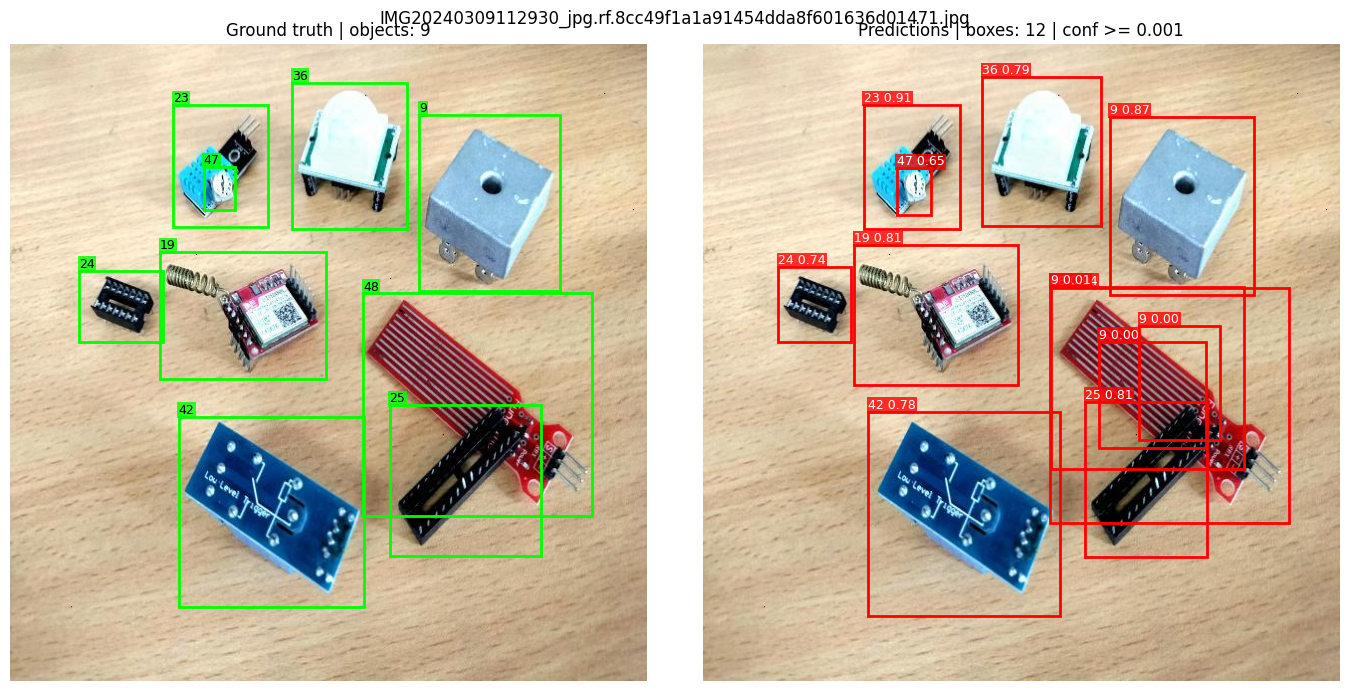

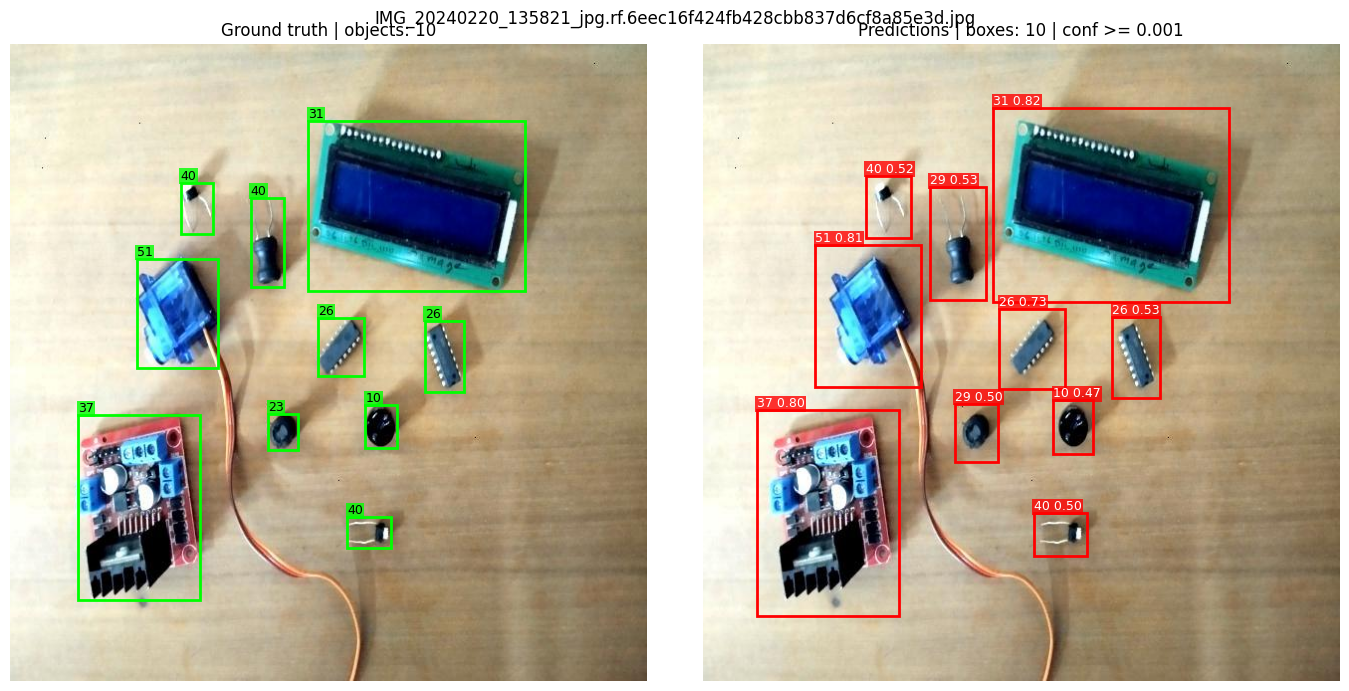

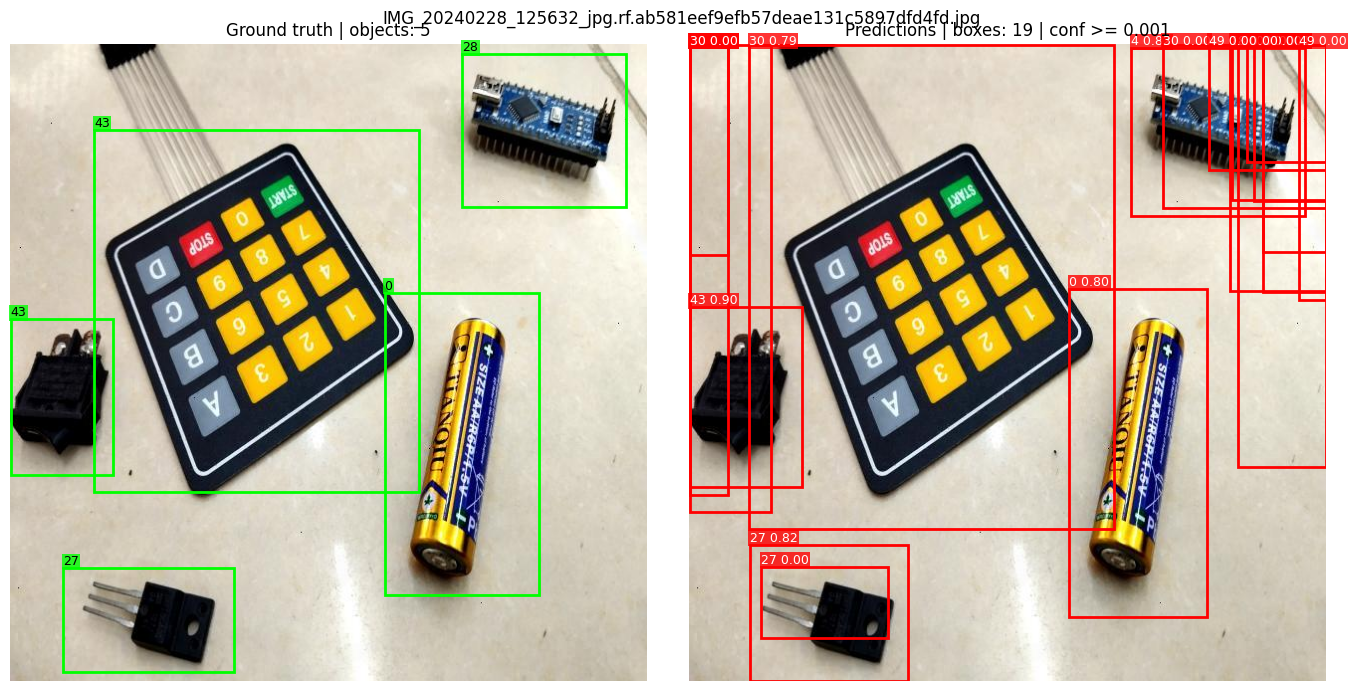

Block 9 finished. Test data was not used.


In [17]:


def show_val_prediction(image_path: Path, conf_threshold: float = None):
    if conf_threshold is None:
        conf_threshold = 0.05

    image = Image.open(image_path).convert("RGB")
    width, height = image.size
    gt_rows = read_yolo_label_file(VAL_LABELS_DIR / f"{image_path.stem}.txt", width, height)

    pred_results = model.predict(
        source=str(image_path),
        imgsz=IMG_SIZE,
        conf=conf_threshold,
        iou=NMS_IOU_THRESHOLD,
        max_det=MAX_DET,
        device=DEVICE,
        verbose=False,
    )
    result = pred_results[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].imshow(image)
    axes[0].set_title(f"Ground truth | objects: {len(gt_rows)}")
    axes[0].axis("off")

    for gt in gt_rows:
        x_min, y_min, x_max, y_max = gt["box"]
        rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, linewidth=2, edgecolor="lime", facecolor="none")
        axes[0].add_patch(rect)
        axes[0].text(x_min, max(y_min - 3, 0), str(gt["class_id"]), fontsize=9, color="black",
                     bbox=dict(facecolor="lime", alpha=0.8, edgecolor="none", pad=1))

    axes[1].imshow(image)
    axes[1].axis("off")

    pred_count = 0
    if result.boxes is not None and len(result.boxes) > 0:
        boxes_xyxy = result.boxes.xyxy.cpu().numpy()
        classes = result.boxes.cls.cpu().numpy().astype(int)
        confs = result.boxes.conf.cpu().numpy()
        pred_count = len(boxes_xyxy)

        for box, class_id, conf in zip(boxes_xyxy, classes, confs):
            x_min, y_min, x_max, y_max = box
            rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, linewidth=2, edgecolor="red", facecolor="none")
            axes[1].add_patch(rect)
            axes[1].text(x_min, max(y_min - 3, 0), f"{class_id} {conf:.2f}", fontsize=9, color="white",
                         bbox=dict(facecolor="red", alpha=0.8, edgecolor="none", pad=1))

    axes[1].set_title(f"Predictions | boxes: {pred_count} | conf >= {conf_threshold}")
    plt.suptitle(image_path.name)
    plt.tight_layout()
    plt.show()

rng = np.random.default_rng(SEED)
sample_val_images = rng.choice(val_image_paths, size=min(5, len(val_image_paths)), replace=False)
for img_path in sample_val_images:
    show_val_prediction(Path(img_path), BEST_CONF_THRESHOLD)

print("Block 9 finished. Test data was not used.")


## 10. Финальный inference на test и один submission

На тесте используется очень слабый порог `conf=0.001` и увеличенный `max_det`, чтобы получить высокий recall. 


In [18]:

from pathlib import Path
from PIL import Image
from ultralytics import YOLO
import pandas as pd
import numpy as np
import random
import shutil
import zipfile
import gc

try:
    from IPython.display import display
except Exception:
    display = print


REQUIRED_VARS = [
    "DATA_ROOT", "PROJECT_DIR", "WORK_ROOT", "BEST_MODEL_PATH", "SAMPLE_SUBMISSION_PATH",
    "IMG_SIZE", "SEED", "N_CLASSES"
]
missing_vars = [name for name in REQUIRED_VARS if name not in globals()]
if missing_vars:
    raise NameError("Не найдены переменные: " + ", ".join(missing_vars) + "\nСначала запусти блоки 0–8.")

DATA_ROOT = Path(DATA_ROOT)
PROJECT_DIR = Path(PROJECT_DIR)
WORK_ROOT = Path(WORK_ROOT)
BEST_MODEL_PATH = Path(BEST_MODEL_PATH)
SAMPLE_SUBMISSION_PATH = Path(SAMPLE_SUBMISSION_PATH)

assert DATA_ROOT.exists(), f"DATA_ROOT не найден: {DATA_ROOT}"
assert PROJECT_DIR.exists(), f"PROJECT_DIR не найден: {PROJECT_DIR}"
assert WORK_ROOT.exists(), f"WORK_ROOT не найден: {WORK_ROOT}"
assert BEST_MODEL_PATH.exists(), f"best.pt не найден: {BEST_MODEL_PATH}"
assert SAMPLE_SUBMISSION_PATH.exists(), f"sample_submission не найден: {SAMPLE_SUBMISSION_PATH}"

if "NMS_IOU_THRESHOLD" not in globals():
    NMS_IOU_THRESHOLD = 0.50
if "MAX_DET" not in globals():
    MAX_DET = 100
if "IMAGE_EXTENSIONS" not in globals():
    IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"}

# Ключевая правка: на TEST оставляем очень слабый порог для высокого recall.
# Это согласовано с validation: RAW_VAL_CONF тоже 0.001.
TEST_CONF_THRESHOLD = 0.001
FINAL_IMG_SIZE = int(globals().get("INFERENCE_IMG_SIZE", IMG_SIZE))
MAX_DET = int(max(MAX_DET, 150))

random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    if torch.cuda.is_available():
        DEVICE = 0
        DEVICE_TYPE = "cuda"
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        DEVICE = "mps"
        DEVICE_TYPE = "mps"
    else:
        DEVICE = "cpu"
        DEVICE_TYPE = "cpu"
except Exception:
    DEVICE = "cpu"
    DEVICE_TYPE = "cpu"

print("FINAL INFERENCE SETTINGS")
print("SEED:", SEED)
print("DEVICE:", DEVICE)
print("DEVICE_TYPE:", DEVICE_TYPE)
print("TRAIN IMG_SIZE:", IMG_SIZE)
print("FINAL INFERENCE_IMG_SIZE:", FINAL_IMG_SIZE)
print("TEST_CONF_THRESHOLD:", TEST_CONF_THRESHOLD)
print("NMS_IOU_THRESHOLD:", NMS_IOU_THRESHOLD)
print("MAX_DET:", MAX_DET)
print("N_CLASSES:", N_CLASSES)
print("BEST_MODEL_PATH:", BEST_MODEL_PATH)


sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH, keep_default_na=False)
assert "image_id" in sample_submission.columns, "В sample_submission нет колонки image_id"
assert len(sample_submission) > 0, "sample_submission пустой"
sample_submission = sample_submission[["image_id"]].copy()
sample_submission["image_id"] = sample_submission["image_id"].astype(str)
print("\nsample_submission rows:", len(sample_submission))
display(sample_submission.head())


def is_real_image_file(path: Path) -> bool:
    return (
        path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
        and not path.name.startswith("._")
        and "__MACOSX" not in str(path)
    )


def collect_image_files_from_dir(folder: Path):
    return sorted([p for p in folder.iterdir() if is_real_image_file(p)])


def find_best_test_images_dir(root: Path, sample_df: pd.DataFrame) -> Path:
    sample_ids = set(sample_df["image_id"].astype(str).tolist())
    candidates = []
    folders = [p for p in root.rglob("images") if p.is_dir()] + [root] + [p for p in root.rglob("*") if p.is_dir()]
    seen = set()

    for folder in folders:
        if folder in seen:
            continue
        seen.add(folder)

        folder_str = str(folder).lower()
        if "__macosx" in folder_str:
            continue
        if "/train/" in folder_str or folder_str.endswith("/train") or "/val/" in folder_str or folder_str.endswith("/val"):
            continue
        if "yolo_dataset" in folder_str:
            continue
        if "cv_kaggle_work" in folder_str:
            continue

        files = collect_image_files_from_dir(folder)
        if len(files) == 0:
            continue

        stems = set(p.stem for p in files)
        names = set(p.name for p in files)
        matches = len(stems & sample_ids) + len(names & sample_ids)
        candidates.append({"folder": folder, "n_files": len(files), "matches": matches})

    if len(candidates) == 0:
        raise FileNotFoundError(f"Не найдена папка с test images внутри {root}")

    candidates_df = pd.DataFrame(candidates).drop_duplicates(subset=["folder"])
    candidates_df = candidates_df.sort_values(["matches", "n_files"], ascending=[False, False]).reset_index(drop=True)
    print("\nTest image folder candidates:")
    display(candidates_df.head(10))

    best = candidates_df.iloc[0]
    if int(best["matches"]) == 0:
        print("WARNING: нет совпадений image_id с именами файлов. Всё равно беру папку с максимумом картинок.")
    return Path(best["folder"])


TEST_SEARCH_ROOT = DATA_ROOT

if "TEST_ZIP_PATH" in globals() and Path(TEST_ZIP_PATH).exists():
    TEST_ZIP_PATH = Path(TEST_ZIP_PATH)
    TEST_RAW_DIR = WORK_ROOT / "raw_data" / "test_extracted_final"
    TEST_RAW_DIR.mkdir(parents=True, exist_ok=True)
    LOCAL_TEST_ZIP_PATH = WORK_ROOT / TEST_ZIP_PATH.name

    if (not LOCAL_TEST_ZIP_PATH.exists()) or (LOCAL_TEST_ZIP_PATH.stat().st_size != TEST_ZIP_PATH.stat().st_size):
        print("Copying test.zip to local runtime...")
        shutil.copy2(TEST_ZIP_PATH, LOCAL_TEST_ZIP_PATH)
    else:
        print("Local test.zip already exists.")

    if not any(TEST_RAW_DIR.iterdir()):
        print("Extracting test.zip...")
        with zipfile.ZipFile(LOCAL_TEST_ZIP_PATH, "r") as z:
            z.extractall(TEST_RAW_DIR)
        print("Test extraction finished.")
    else:
        print("Test directory already contains files, extraction skipped.")

    TEST_SEARCH_ROOT = TEST_RAW_DIR

TEST_IMAGES_DIR = find_best_test_images_dir(TEST_SEARCH_ROOT, sample_submission)
test_image_paths = collect_image_files_from_dir(TEST_IMAGES_DIR)

print("\nTEST_IMAGES_DIR:", TEST_IMAGES_DIR)
print("Test images found:", len(test_image_paths))

if len(test_image_paths) == 0:
    raise FileNotFoundError(f"В папке {TEST_IMAGES_DIR} нет изображений.")

file_by_stem = {p.stem: p for p in test_image_paths}
file_by_name = {p.name: p for p in test_image_paths}


def resolve_image_path(image_id: str):
    image_id = str(image_id)
    if image_id in file_by_name:
        return file_by_name[image_id]
    if image_id in file_by_stem:
        return file_by_stem[image_id]
    for ext in sorted(IMAGE_EXTENSIONS):
        candidate_name = image_id + ext
        if candidate_name in file_by_name:
            return file_by_name[candidate_name]
    return None


sample_submission["image_path"] = sample_submission["image_id"].apply(resolve_image_path)
missing = int(sample_submission["image_path"].isna().sum())
print("Missing image files for sample rows:", missing)

if missing > 0:
    display(sample_submission[sample_submission["image_path"].isna()].head(10))
    raise FileNotFoundError("Не все image_id из sample_submission найдены среди test images.")

# ------------------------------------------------------------
# 10.4. Inference
# ------------------------------------------------------------
def clear_gpu_final():
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass


def format_prediction_string(result, width: int, height: int) -> str:
    if result.boxes is None or len(result.boxes) == 0:
        return " "

    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)

    parts = []
    for box, conf, cls in zip(boxes, confs, classes):
        cls = int(cls)
        conf = float(conf)

        if cls < 0 or cls >= N_CLASSES:
            continue
        if conf < TEST_CONF_THRESHOLD:
            continue

        x1, y1, x2, y2 = box.astype(float)
        x1 = float(np.clip(x1, 0, width))
        y1 = float(np.clip(y1, 0, height))
        x2 = float(np.clip(x2, 0, width))
        y2 = float(np.clip(y2, 0, height))

        if x2 <= x1 or y2 <= y1:
            continue

        parts.extend([
            str(cls),
            f"{conf:.6f}",
            f"{x1:.2f}",
            f"{y1:.2f}",
            f"{x2:.2f}",
            f"{y2:.2f}",
        ])

    return " ".join(parts) if parts else " "


model = YOLO(str(BEST_MODEL_PATH))
print("\nModel loaded:", BEST_MODEL_PATH)
print("\nRunning final one-by-one inference...")
print("Raw TEST conf:", TEST_CONF_THRESHOLD)
print("FINAL_IMG_SIZE:", FINAL_IMG_SIZE)
print("NMS_IOU_THRESHOLD:", NMS_IOU_THRESHOLD)
print("MAX_DET:", MAX_DET)
print("TTA/augment:", False)

rows = []
boxes_per_image = []
current_img_size = int(FINAL_IMG_SIZE)

for idx, row in sample_submission.reset_index(drop=True).iterrows():
    image_id = row["image_id"]
    image_path = Path(row["image_path"])

    with Image.open(image_path) as img:
        width, height = img.size

    try:
        results = model.predict(
            source=str(image_path),
            imgsz=current_img_size,
            conf=TEST_CONF_THRESHOLD,
            iou=float(NMS_IOU_THRESHOLD),
            max_det=MAX_DET,
            device=DEVICE,
            augment=False,
            half=(DEVICE_TYPE == "cuda"),
            verbose=False,
        )
    except RuntimeError as e:
        message = str(e).lower()
        if "out of memory" in message or "cuda" in message:
            print(f"OOM on image {idx + 1}. Fallback inference size -> 640")
            clear_gpu_final()
            current_img_size = 640
            results = model.predict(
                source=str(image_path),
                imgsz=current_img_size,
                conf=TEST_CONF_THRESHOLD,
                iou=float(NMS_IOU_THRESHOLD),
                max_det=MAX_DET,
                device=DEVICE,
                augment=False,
                half=(DEVICE_TYPE == "cuda"),
                verbose=False,
            )
        else:
            raise

    result = results[0]
    pred_string = format_prediction_string(result, width, height)
    n_boxes = 0 if pred_string.strip() == "" else len(pred_string.split()) // 6
    boxes_per_image.append(n_boxes)

    rows.append({
        "image_id": str(image_id),
        "PredictionString": pred_string if pred_string.strip() != "" else " ",
    })

    del results, result
    clear_gpu_final()

    if (idx + 1) % 25 == 0 or (idx + 1) == len(sample_submission):
        print(f"Processed {idx + 1}/{len(sample_submission)}")

FINAL_IMG_SIZE = current_img_size

df_submission = pd.DataFrame(rows)[["image_id", "PredictionString"]]

def validate_submission_df(df: pd.DataFrame, sample_df: pd.DataFrame):
    assert list(df.columns) == ["image_id", "PredictionString"], "wrong columns"
    assert len(df) == len(sample_df), "wrong row count"
    assert df["image_id"].astype(str).tolist() == sample_df["image_id"].astype(str).tolist(), "image_id order changed"

    total_boxes = 0
    bad_rows = []
    for row_idx, pred in enumerate(df["PredictionString"].fillna(" ").astype(str)):
        pred = pred.strip()
        if pred == "":
            continue
        tokens = pred.split()
        if len(tokens) % 6 != 0:
            bad_rows.append((row_idx, len(tokens), pred[:120]))
            continue
        total_boxes += len(tokens) // 6
        for i in range(0, len(tokens), 6):
            cls = int(float(tokens[i]))
            conf = float(tokens[i + 1])
            x1, y1, x2, y2 = map(float, tokens[i + 2:i + 6])
            if not (0 <= cls < N_CLASSES):
                raise ValueError(f"bad class {cls} in row {row_idx}")
            if not (0.0 <= conf <= 1.0):
                raise ValueError(f"bad confidence {conf} in row {row_idx}")
            if not (x2 > x1 and y2 > y1):
                raise ValueError(f"bad box in row {row_idx}: {(x1, y1, x2, y2)}")
    assert len(bad_rows) == 0, f"Строки с неправильным числом токенов: {bad_rows[:5]}"
    return total_boxes

# ВАЖНО: для Kaggle пустые предсказания сохраняем как пробел, чтобы не было null values.
df_submission["PredictionString"] = df_submission["PredictionString"].fillna(" ").astype(str)
df_submission["PredictionString"] = df_submission["PredictionString"].apply(lambda x: x if str(x).strip() != "" else " ")
df_submission["image_id"] = df_submission["image_id"].astype(str)

assert df_submission["image_id"].isna().sum() == 0, "В image_id есть null"
assert df_submission["PredictionString"].isna().sum() == 0, "В PredictionString есть null"

total_boxes = validate_submission_df(df_submission, sample_submission)

FINAL_SUBMISSION_PATH = Path.cwd() / "sample_submission.csv"
df_submission.to_csv(FINAL_SUBMISSION_PATH, index=False)

# Не создаём другие submission-файлы: на выходе один CSV.
print("\nГОТОВО. Создан один submission-файл:")
print(FINAL_SUBMISSION_PATH)
print("Rows:", len(df_submission))
print("Images with predictions:", int(np.sum(np.array(boxes_per_image) > 0)))
print("Images without predictions:", int(np.sum(np.array(boxes_per_image) == 0)))
print("Total predicted boxes:", int(total_boxes))
print("Mean boxes per image:", float(np.mean(boxes_per_image)) if boxes_per_image else 0.0)
print("Null values:")
print(df_submission.isna().sum())

display(df_submission.head())


FINAL INFERENCE SETTINGS
SEED: 993
DEVICE: 0
DEVICE_TYPE: cuda
TRAIN IMG_SIZE: 768
FINAL INFERENCE_IMG_SIZE: 768
TEST_CONF_THRESHOLD: 0.001
NMS_IOU_THRESHOLD: 0.5
MAX_DET: 150
N_CLASSES: 52
BEST_MODEL_PATH: /kaggle/working/cv_kaggle_work/yolo_runs/yolo11l_seed993_11l_768_bs8_fresh_target25_from0_fastsafe/weights/best.pt

sample_submission rows: 424


,image_id
0,IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1a...
1,IMG20240228122949_jpg.rf.f763b523e7bb4e7250796...
2,IMG20240228122955_jpg.rf.18d6c6ad9c8c69153da34...
3,IMG20240228123115_jpg.rf.3b9ae83d0bc7242bafe52...
4,IMG20240228123131_jpg.rf.84cf43cf1c7a8d09dc507...



Test image folder candidates:


,folder,n_files,matches
0,/kaggle/input/datasets/anasteysha13/data-for-d...,424,424



TEST_IMAGES_DIR: /kaggle/input/datasets/anasteysha13/data-for-dl/2026-cv-competition/test/test/images
Test images found: 424
Missing image files for sample rows: 0

Model loaded: /kaggle/working/cv_kaggle_work/yolo_runs/yolo11l_seed993_11l_768_bs8_fresh_target25_from0_fastsafe/weights/best.pt

Running final one-by-one inference...
Raw TEST conf: 0.001
FINAL_IMG_SIZE: 768
NMS_IOU_THRESHOLD: 0.5
MAX_DET: 150
TTA/augment: False
Processed 25/424
Processed 50/424
Processed 75/424
Processed 100/424
Processed 125/424
Processed 150/424
Processed 175/424
Processed 200/424
Processed 225/424
Processed 250/424
Processed 275/424
Processed 300/424
Processed 325/424
Processed 350/424
Processed 375/424
Processed 400/424
Processed 424/424

ГОТОВО. Создан один submission-файл:
/kaggle/working/sample_submission.csv
Rows: 424
Images with predictions: 424
Images without predictions: 0
Total predicted boxes: 14693
Mean boxes per image: 34.653301886792455
Null values:
image_id            0
PredictionString 

,image_id,PredictionString
0,IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1a...,30 0.771973 161.77 355.00 415.83 542.50 28 0.6...
1,IMG20240228122949_jpg.rf.f763b523e7bb4e7250796...,30 0.255371 32.92 100.42 369.38 357.50 41 0.12...
2,IMG20240228122955_jpg.rf.18d6c6ad9c8c69153da34...,30 0.756348 134.17 226.25 420.00 590.00 0 0.74...
3,IMG20240228123115_jpg.rf.3b9ae83d0bc7242bafe52...,30 0.853027 40.21 78.33 278.12 385.83 51 0.686...
4,IMG20240228123131_jpg.rf.84cf43cf1c7a8d09dc507...,43 0.874023 455.00 187.50 530.83 298.75 0 0.80...


In [19]:


from pathlib import Path
import pandas as pd
import numpy as np

sub = pd.read_csv(FINAL_SUBMISSION_PATH, keep_default_na=False)

print("Файл для загрузки в Kaggle:")
print(FINAL_SUBMISSION_PATH)
print("Shape:", sub.shape)
print("Columns:", sub.columns.tolist())
print("Null values:")
print(sub.isna().sum())

assert list(sub.columns) == ["image_id", "PredictionString"], "Неверные колонки"
assert sub["image_id"].isna().sum() == 0, "В image_id есть null"
assert sub["PredictionString"].isna().sum() == 0, "В PredictionString есть null"

bad_empty = (sub["PredictionString"].astype(str).str.strip() == "").sum()
print("Пустых PredictionString:", int(bad_empty))




Файл для загрузки в Kaggle:
/kaggle/working/sample_submission.csv
Shape: (424, 2)
Columns: ['image_id', 'PredictionString']
Null values:
image_id            0
PredictionString    0
dtype: int64
Пустых PredictionString: 0
